In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# CONFIG
# ============================================================

MEMBER      = "Kalhara"
MODEL_NAME  = "resnet"

# Dataset is already available directly in Google Drive.
# We are NOT using dataset.zip here.
DRIVE_ZIP   = None

# Your batch folders are here:
# /content/drive/MyDrive/KL_Batches/batch_500
DRIVE_DATA  = "/content/drive/MyDrive/KL_Batches"

# Where results will be saved
DRIVE_OUT   = "/content/drive/MyDrive/KL_Batches/runs"

# Fast local disk
LOCAL_DATA  = "/content/data"

# ------------------------------------------------------------
# RUN ONE BATCH AT A TIME
# ------------------------------------------------------------
BATCHES     = [500]

# ------------------------------------------------------------
# TRAINING
# ------------------------------------------------------------
EPOCHS      = 30
BATCH_SIZE  = 32

# Explicitly use 1e-4
LR          = 1e-4

# ------------------------------------------------------------
# SHARED POLICY
# ------------------------------------------------------------
IMAGE_SIZE  = 224
NUM_CLASSES = 5
SEED        = 42

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

SAVE_CHECKPOINTS = True

print("Model:", MODEL_NAME)
print("Batches:", BATCHES)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LR)

Model: resnet
Batches: [500]
Epochs: 30
Batch size: 32
Learning rate: 0.0001


In [ ]:
# ============================================================
# DATA ROOT
# ============================================================

import os

DATA_ROOT = DRIVE_DATA

print("DATA_ROOT =", DATA_ROOT)

print("\nAvailable batches:")
print(sorted(
    d for d in os.listdir(DATA_ROOT)
    if d.startswith("batch_")
))

DATA_ROOT = /content/drive/MyDrive/KL_Batches

Available batches:
['batch_1000', 'batch_500']


In [ ]:
# ============================================================
# IMPORTS + SEED
# ============================================================

import os
import json
import random
import copy

import numpy as np
import torch
import torch.nn as nn

from PIL import Image

from torch.utils.data import DataLoader, WeightedRandomSampler

from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    cohen_kappa_score,
    confusion_matrix
)

def set_seed(s=SEED):
    random.seed(s)
    np.random.seed(s)

    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
# ============================================================
# 16-BIT GRAYSCALE TIFF LOADER
# ============================================================

def load_16bit_xray(path):
    """
    Load a 16-bit grayscale TIFF.

    Original:
        uint16, approximately 0-65535

    Output:
        float32 tensor
        shape = [3, H, W]
        range approximately 0-1
    """

    img = Image.open(path)

    # Read the original 16-bit pixel values
    arr = np.array(img, dtype=np.uint16)

    # Convert to float32
    arr = arr.astype(np.float32)

    # Fixed scaling to the full uint16 range
    arr = arr / 65535.0

    # Convert to tensor: H,W -> 1,H,W
    tensor = torch.from_numpy(arr).unsqueeze(0)

    # Grayscale -> 3 identical channels
    tensor = tensor.repeat(3, 1, 1)

    return tensor

In [ ]:
# ============================================================
# TRANSFORMS
# ============================================================

def train_transform():
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

        # Moderate geometric augmentation
        transforms.RandomAffine(
            degrees=7,
            translate=(0.03, 0.03),
            scale=(0.95, 1.05)
        ),

        # Moderate intensity augmentation
        transforms.ColorJitter(
            brightness=0.10,
            contrast=0.10
        ),

        # ImageNet normalization for pretrained ResNet
        transforms.Normalize(MEAN, STD)
    ])


def eval_transform():
    # NO augmentation for frozen test
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.Normalize(MEAN, STD)
    ])

In [ ]:
# ============================================================
# DATASET CREATION
# ============================================================

def make_datasets(batch):

    bdir = os.path.join(DATA_ROOT, f"batch_{batch}")

    train_dir = os.path.join(bdir, "train")
    test_dir  = os.path.join(bdir, "test")

    tr_ds = ImageFolder(
        train_dir,
        loader=load_16bit_xray,
        transform=train_transform()
    )

    te_ds = ImageFolder(
        test_dir,
        loader=load_16bit_xray,
        transform=eval_transform()
    )

    return tr_ds, te_ds

In [ ]:
# ============================================================
# WEIGHTED OVERSAMPLING
# ============================================================

def make_weighted_sampler(labels):

    labels = np.asarray(labels)

    counts = np.bincount(
        labels,
        minlength=NUM_CLASSES
    )

    weights = (
        1.0 /
        np.maximum(counts, 1)
    )[labels]

    sampler = WeightedRandomSampler(
        torch.DoubleTensor(weights),
        num_samples=len(weights),
        replacement=True
    )

    return sampler

In [ ]:
# ============================================================
# METRICS
# ============================================================

def compute_metrics(yt, yp):

    wp, wr, wf, _ = precision_recall_fscore_support(
        yt,
        yp,
        average="weighted",
        zero_division=0
    )

    mp, mr, mf, _ = precision_recall_fscore_support(
        yt,
        yp,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": float(
            accuracy_score(yt, yp)
        ),

        "weighted_precision": float(wp),
        "weighted_recall": float(wr),
        "weighted_f1": float(wf),

        "macro_precision": float(mp),
        "macro_recall": float(mr),
        "macro_f1": float(mf),

        "cohen_kappa": float(
            cohen_kappa_score(yt, yp)
        ),

        "quadratic_weighted_kappa": float(
            cohen_kappa_score(
                yt,
                yp,
                weights="quadratic"
            )
        )
    }

In [ ]:
# ============================================================
# DATASET CHECK
# ============================================================

tr_check, te_check = make_datasets(500)

print("TRAIN")
print("Total:", len(tr_check))
print("Classes:", tr_check.classes)
print("Mapping:", tr_check.class_to_idx)

for i, cls in enumerate(tr_check.classes):
    count = sum(
        label == i
        for _, label in tr_check.samples
    )
    print(f"{cls}: {count}")

print("\nTEST")
print("Total:", len(te_check))
print("Classes:", te_check.classes)
print("Mapping:", te_check.class_to_idx)

for i, cls in enumerate(te_check.classes):
    count = sum(
        label == i
        for _, label in te_check.samples
    )
    print(f"{cls}: {count}")

TRAIN
Total: 382
Classes: ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Mapping: {'Grade 0': 0, 'Grade 1': 1, 'Grade 2': 2, 'Grade 3': 3, 'Grade 4': 4}
Grade 0: 168
Grade 1: 31
Grade 2: 89
Grade 3: 23
Grade 4: 71

TEST
Total: 939
Classes: ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Mapping: {'Grade 0': 0, 'Grade 1': 1, 'Grade 2': 2, 'Grade 3': 3, 'Grade 4': 4}
Grade 0: 508
Grade 1: 98
Grade 2: 255
Grade 3: 62
Grade 4: 16


Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Tensor min: -2.1179039478302
Tensor max: 1.3559703826904297
Tensor mean: -0.425383985042572
Tensor std: 0.812739908695221
Label: Grade 0


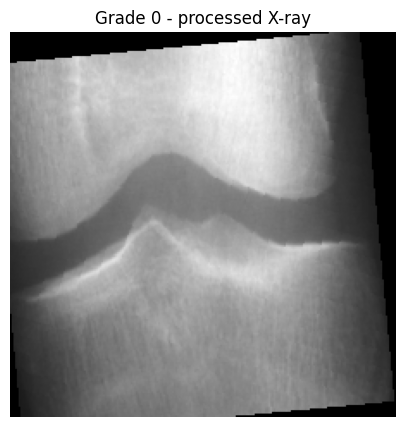

In [ ]:
# ============================================================
# CHECK PREPROCESSED IMAGE
# ============================================================

import matplotlib.pyplot as plt

img, label = tr_check[0]

print("Tensor shape:", img.shape)
print("Tensor dtype:", img.dtype)
print("Tensor min:", img.min().item())
print("Tensor max:", img.max().item())
print("Tensor mean:", img.mean().item())
print("Tensor std:", img.std().item())
print("Label:", tr_check.classes[label])

# Undo ImageNet normalization for visualization
display_img = img.clone()

for c in range(3):
    display_img[c] = (
        display_img[c] * STD[c] + MEAN[c]
    )

display_img = display_img.clamp(0, 1)

plt.figure(figsize=(7, 5))
plt.imshow(
    display_img[0].numpy(),
    cmap="gray"
)
plt.title(
    f"{tr_check.classes[label]} - processed X-ray"
)
plt.axis("off")
plt.show()

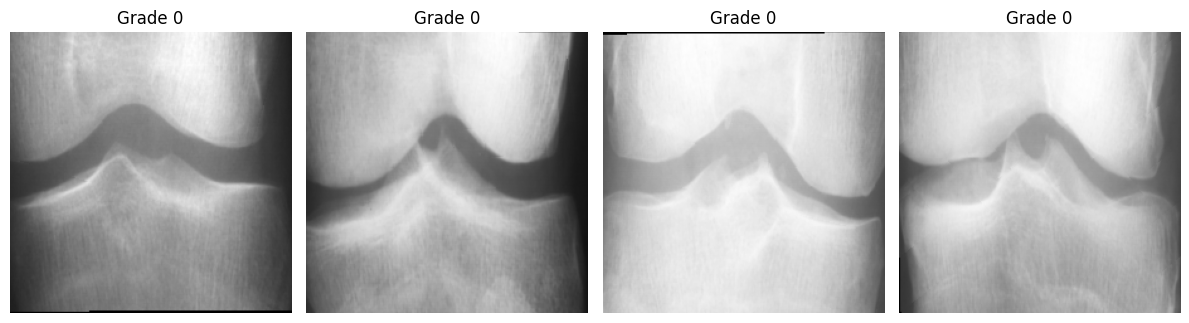

In [ ]:
# ============================================================
# AUGMENTATION CHECK
# ============================================================

raw_ds = ImageFolder(
    os.path.join(
        DATA_ROOT,
        "batch_500",
        "train"
    ),
    loader=load_16bit_xray,
    transform=None
)

plt.figure(figsize=(12, 4))

for i in range(4):

    raw_img, label = raw_ds[i]

    aug_img = train_transform()(raw_img.clone())

    # Undo normalization
    show_img = aug_img.clone()

    for c in range(3):
        show_img[c] = (
            show_img[c] * STD[c] + MEAN[c]
        )

    show_img = show_img.clamp(0, 1)

    ax = plt.subplot(1, 4, i + 1)

    ax.imshow(
        show_img[0].numpy(),
        cmap="gray"
    )

    ax.set_title(
        raw_ds.classes[label]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# MODEL
# ============================================================

class SimpleCNN(nn.Module):

    def __init__(self, n):

        super().__init__()

        def blk(i, o):
            return nn.Sequential(
                nn.Conv2d(
                    i,
                    o,
                    3,
                    padding=1
                ),
                nn.BatchNorm2d(o),
                nn.ReLU(True),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            blk(3, 32),
            blk(32, 64),
            blk(64, 128),

            nn.Conv2d(
                128,
                256,
                3,
                padding=1
            ),

            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, n)
        )

    def forward(self, x):
        return self.classifier(
            self.features(x)
        )


def build_model(name, n=NUM_CLASSES):

    name = name.lower()

    if name == "resnet":

        model = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            n
        )

    elif name == "densenet":

        model = models.densenet201(
            weights=models.DenseNet201_Weights.DEFAULT
        )

        model.classifier = nn.Linear(
            model.classifier.in_features,
            n
        )

    elif name == "vit":

        model = models.vit_b_16(
            weights=models.ViT_B_16_Weights.DEFAULT
        )

        model.heads.head = nn.Linear(
            model.heads.head.in_features,
            n
        )

    elif name == "cnn":

        model = SimpleCNN(n)

    else:
        raise ValueError(name)

    return model

In [ ]:
# ============================================================
# TRAINING
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    total_loss = 0.0
    correct = 0
    n = 0

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        output = model(x)

        loss = criterion(
            output,
            y
        )

        loss.backward()
        optimizer.step()

        total_loss += (
            loss.item() * x.size(0)
        )

        correct += (
            output.argmax(1) == y
        ).sum().item()

        n += x.size(0)

    return (
        total_loss / n,
        correct / n
    )


@torch.no_grad()
def evaluate(model, loader):

    model.eval()

    ys = []
    ps = []

    for x, y in loader:

        output = model(
            x.to(device)
        )

        predictions = output.argmax(1)

        ps.extend(
            predictions.cpu().numpy()
        )

        ys.extend(
            y.numpy()
        )

    return (
        np.array(ys),
        np.array(ps)
    )

Device: cuda


In [ ]:
# ============================================================
# RUN ONE BATCH
# ============================================================

def run_batch(batch):

    print("\n" + "=" * 60)
    print(f"STARTING {MODEL_NAME.upper()} - BATCH {batch}")
    print("=" * 60)

    set_seed(SEED)

    # --------------------------------------------------------
    # Paths
    # --------------------------------------------------------

    bdir = os.path.join(
        DATA_ROOT,
        f"batch_{batch}"
    )

    train_dir = os.path.join(
        bdir,
        "train"
    )

    test_dir = os.path.join(
        bdir,
        "test"
    )

    # --------------------------------------------------------
    # Datasets
    # --------------------------------------------------------

    tr_ds = ImageFolder(
        train_dir,
        loader=load_16bit_xray,
        transform=train_transform()
    )

    te_ds = ImageFolder(
        test_dir,
        loader=load_16bit_xray,
        transform=eval_transform()
    )

    # --------------------------------------------------------
    # Class mapping check
    # --------------------------------------------------------

    print("\nClass mapping:")
    print(tr_ds.class_to_idx)

    if tr_ds.class_to_idx != te_ds.class_to_idx:
        raise ValueError(
            "TRAIN and TEST class mappings do not match!"
        )

    # --------------------------------------------------------
    # Original training class counts
    # --------------------------------------------------------

    train_labels = [
        label
        for _, label in tr_ds.samples
    ]

    counts = np.bincount(
        train_labels,
        minlength=NUM_CLASSES
    )

    print("\nTraining distribution:")

    for i, cls in enumerate(tr_ds.classes):
        print(
            f"{cls}: {counts[i]}"
        )

    # --------------------------------------------------------
    # Weighted sampler
    # --------------------------------------------------------

    sampler = make_weighted_sampler(
        train_labels
    )

    # --------------------------------------------------------
    # DataLoaders
    # --------------------------------------------------------

    train_loader = DataLoader(
        tr_ds,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        te_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = build_model(
        MODEL_NAME
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    history = []

    for epoch in range(
        1,
        EPOCHS + 1
    ):

        loss, acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "train_loss": float(loss),
            "train_accuracy": float(acc),
            "learning_rate": float(current_lr)
        })

        print(
            f"batch_{batch} "
            f"ep{epoch:02d} | "
            f"train_loss {loss:.3f} | "
            f"train_acc {acc:.3f} | "
            f"lr {current_lr:.7f}"
        )

    # --------------------------------------------------------
    # FROZEN TEST
    # Evaluate only after training is complete
    # --------------------------------------------------------

    print("\nEvaluating frozen test set...")

    yt, yp = evaluate(
        model,
        test_loader
    )

    res = compute_metrics(
        yt,
        yp
    )

    res.update({
        "model": MODEL_NAME,
        "batch": batch,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LR
    })

    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    outdir = os.path.join(
        DRIVE_OUT,
        MODEL_NAME
    )

    os.makedirs(
        outdir,
        exist_ok=True
    )

    # Metrics
    with open(
        os.path.join(
            outdir,
            f"batch_{batch}_metrics.json"
        ),
        "w"
    ) as f:

        json.dump(
            res,
            f,
            indent=2
        )

    # Confusion matrix
    cm = confusion_matrix(
        yt,
        yp,
        labels=list(
            range(NUM_CLASSES)
        )
    )

    np.savetxt(
        os.path.join(
            outdir,
            f"batch_{batch}_confusion.csv"
        ),
        cm,
        fmt="%d",
        delimiter=","
    )

    # Training history
    with open(
        os.path.join(
            outdir,
            f"batch_{batch}_history.json"
        ),
        "w"
    ) as f:

        json.dump(
            history,
            f,
            indent=2
        )

    # Checkpoint
    if SAVE_CHECKPOINTS:

        torch.save(
            model.state_dict(),
            os.path.join(
                outdir,
                f"batch_{batch}_final.pth"
            )
        )

    print("\n" + "-" * 60)
    print("FINAL TEST RESULTS")
    print("-" * 60)

    print(
        f"Accuracy : {res['accuracy']:.4f}"
    )

    print(
        f"Macro F1 : {res['macro_f1']:.4f}"
    )

    print(
        f"Weighted F1 : {res['weighted_f1']:.4f}"
    )

    print(
        f"Cohen Kappa : {res['cohen_kappa']:.4f}"
    )

    print(
        f"QWK : {res['quadratic_weighted_kappa']:.4f}"
    )

    print("\nConfusion Matrix:")
    print(cm)

    return res

In [ ]:
# ============================================================
# RUN BATCH 500
# ============================================================

all_results = []

for b in BATCHES:

    print(
        f"\n===== {MODEL_NAME} batch_{b} ====="
    )

    result = run_batch(b)

    all_results.append(result)

print("\nBatch 500 done.")


===== resnet batch_500 =====

STARTING RESNET - BATCH 500

Class mapping:
{'Grade 0': 0, 'Grade 1': 1, 'Grade 2': 2, 'Grade 3': 3, 'Grade 4': 4}

Training distribution:
Grade 0: 168
Grade 1: 31
Grade 2: 89
Grade 3: 23
Grade 4: 71
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 64.2MB/s]
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


batch_500 ep01 | train_loss 1.576 | train_acc 0.288 | lr 0.0000997
batch_500 ep02 | train_loss 1.486 | train_acc 0.429 | lr 0.0000989
batch_500 ep03 | train_loss 1.331 | train_acc 0.510 | lr 0.0000976
batch_500 ep04 | train_loss 1.095 | train_acc 0.631 | lr 0.0000957
batch_500 ep05 | train_loss 0.892 | train_acc 0.694 | lr 0.0000933
batch_500 ep06 | train_loss 0.711 | train_acc 0.767 | lr 0.0000905
batch_500 ep07 | train_loss 0.495 | train_acc 0.874 | lr 0.0000872
batch_500 ep08 | train_loss 0.379 | train_acc 0.872 | lr 0.0000835
batch_500 ep09 | train_loss 0.292 | train_acc 0.914 | lr 0.0000794
batch_500 ep10 | train_loss 0.301 | train_acc 0.898 | lr 0.0000750
batch_500 ep11 | train_loss 0.228 | train_acc 0.935 | lr 0.0000703
batch_500 ep12 | train_loss 0.213 | train_acc 0.924 | lr 0.0000655


In [ ]:
# ============================================================
# SETUP FOR RESULTS / CONFUSION MATRIX
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix

RESNET — BATCH 500
accuracy: 0.6198083067092651
weighted_precision: 0.5714512439430047
weighted_recall: 0.6198083067092651
weighted_f1: 0.5757848580692978
macro_precision: 0.41585357904415987
macro_recall: 0.47886562016221274
macro_f1: 0.3797760284777562
cohen_kappa: 0.33132865375293974
quadratic_weighted_kappa: 0.6349542285205834
model: resnet
batch: 500
epochs: 30
batch_size: 32
learning_rate: 0.0001

Confusion Matrix:
[[449  10  47   0   2]
 [ 80   2  16   0   0]
 [108  12 108   8  19]
 [  2   0  30   8  22]
 [  0   0   1   0  15]]


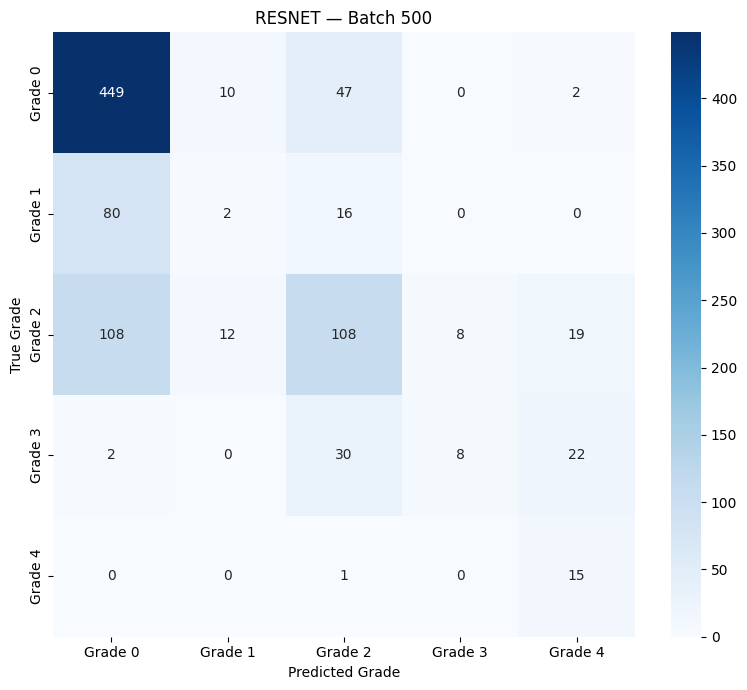


Confusion matrix graph saved to:
/content/drive/MyDrive/KL_Batches/runs/resnet/batch_500_confusion_matrix.png

Results summary saved to:
/content/drive/MyDrive/KL_Batches/runs/resnet_batch_500_summary.csv


In [ ]:
# ============================================================
# LOAD, PRINT, GRAPH AND SAVE RESULTS AUTOMATICALLY
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Automatically use the current model and batch
model_name = MODEL_NAME
batch = BATCHES[-1]

outdir = os.path.join(DRIVE_OUT, model_name)

metrics_path = os.path.join(
    outdir, f"batch_{batch}_metrics.json"
)

cm_path = os.path.join(
    outdir, f"batch_{batch}_confusion.csv"
)

# ------------------------------------------------------------
# LOAD SAVED METRICS
# ------------------------------------------------------------

with open(metrics_path, "r") as f:
    results = json.load(f)

print("=" * 60)
print(f"{model_name.upper()} — BATCH {batch}")
print("=" * 60)

for key, value in results.items():
    print(f"{key}: {value}")

# ------------------------------------------------------------
# LOAD SAVED CONFUSION MATRIX
# ------------------------------------------------------------

cm = np.loadtxt(cm_path, delimiter=",", dtype=int)

classes = [
    "Grade 0",
    "Grade 1",
    "Grade 2",
    "Grade 3",
    "Grade 4"
]

print("\nConfusion Matrix:")
print(cm)

# ------------------------------------------------------------
# GRAPHICAL CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(8, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title(f"{model_name.upper()} — Batch {batch}")
plt.xlabel("Predicted Grade")
plt.ylabel("True Grade")

plt.tight_layout()

graph_path = os.path.join(
    outdir,
    f"batch_{batch}_confusion_matrix.png"
)

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("\nConfusion matrix graph saved to:")
print(graph_path)

# ------------------------------------------------------------
# SAVE A CSV SUMMARY FOR COMPARING BATCHES
# ------------------------------------------------------------

summary_path = os.path.join(
    DRIVE_OUT,
    f"{model_name}_batch_{batch}_summary.csv"
)

pd.DataFrame([results]).to_csv(
    summary_path,
    index=False
)

print("\nResults summary saved to:")
print(summary_path)

## **For Batch 1000 Images**

In [ ]:
# ============================================================
# CONFIG
# ============================================================

MEMBER      = "Kalhara"
MODEL_NAME  = "resnet"

# Dataset is already available directly in Google Drive.
# We are NOT using dataset.zip here.
DRIVE_ZIP   = None

# Your batch folders are here:
# /content/drive/MyDrive/KL_Batches/batch_500
DRIVE_DATA  = "/content/drive/MyDrive/KL_Batches"

# Where results will be saved
DRIVE_OUT   = "/content/drive/MyDrive/KL_Batches/runs"

# Fast local disk
LOCAL_DATA  = "/content/data"

# ------------------------------------------------------------
# RUN ONE BATCH AT A TIME
# ------------------------------------------------------------
BATCHES     = [1000]

# ------------------------------------------------------------
# TRAINING
# ------------------------------------------------------------
EPOCHS      = 30
BATCH_SIZE  = 32

# Explicitly use 1e-4
LR          = 1e-4

# ------------------------------------------------------------
# SHARED POLICY
# ------------------------------------------------------------
IMAGE_SIZE  = 224
NUM_CLASSES = 5
SEED        = 42

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

SAVE_CHECKPOINTS = True

print("Model:", MODEL_NAME)
print("Batches:", BATCHES)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LR)

Model: resnet
Batches: [1000]
Epochs: 30
Batch size: 32
Learning rate: 0.0001


In [ ]:
# ============================================================
# DATA ROOT
# ============================================================

import os

DATA_ROOT = DRIVE_DATA

print("DATA_ROOT =", DATA_ROOT)

print("\nAvailable batches:")
print(sorted(
    d for d in os.listdir(DATA_ROOT)
    if d.startswith("batch_")
))

DATA_ROOT = /content/drive/MyDrive/KL_Batches

Available batches:
['batch_1000', 'batch_500']


In [ ]:
# ============================================================
# IMPORTS + SEED
# ============================================================

import os
import json
import random
import copy

import numpy as np
import torch
import torch.nn as nn

from PIL import Image

from torch.utils.data import DataLoader, WeightedRandomSampler

from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    cohen_kappa_score,
    confusion_matrix
)

def set_seed(s=SEED):
    random.seed(s)
    np.random.seed(s)

    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
# ============================================================
# 16-BIT GRAYSCALE TIFF LOADER
# ============================================================

def load_16bit_xray(path):
    """
    Load a 16-bit grayscale TIFF.

    Original:
        uint16, approximately 0-65535

    Output:
        float32 tensor
        shape = [3, H, W]
        range approximately 0-1
    """

    img = Image.open(path)

    # Read the original 16-bit pixel values
    arr = np.array(img, dtype=np.uint16)

    # Convert to float32
    arr = arr.astype(np.float32)

    # Fixed scaling to the full uint16 range
    arr = arr / 65535.0

    # Convert to tensor: H,W -> 1,H,W
    tensor = torch.from_numpy(arr).unsqueeze(0)

    # Grayscale -> 3 identical channels
    tensor = tensor.repeat(3, 1, 1)

    return tensor

In [ ]:
# ============================================================
# TRANSFORMS
# ============================================================

def train_transform():
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

        # Moderate geometric augmentation
        transforms.RandomAffine(
            degrees=7,
            translate=(0.03, 0.03),
            scale=(0.95, 1.05)
        ),

        # Moderate intensity augmentation
        transforms.ColorJitter(
            brightness=0.10,
            contrast=0.10
        ),

        # ImageNet normalization for pretrained ResNet
        transforms.Normalize(MEAN, STD)
    ])


def eval_transform():
    # NO augmentation for frozen test
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.Normalize(MEAN, STD)
    ])

In [ ]:
# ============================================================
# DATASET CREATION
# ============================================================

def make_datasets(batch):

    bdir = os.path.join(DATA_ROOT, f"batch_{batch}")

    train_dir = os.path.join(bdir, "train")
    test_dir  = os.path.join(bdir, "test")

    tr_ds = ImageFolder(
        train_dir,
        loader=load_16bit_xray,
        transform=train_transform()
    )

    te_ds = ImageFolder(
        test_dir,
        loader=load_16bit_xray,
        transform=eval_transform()
    )

    return tr_ds, te_ds

In [ ]:
# ============================================================
# WEIGHTED OVERSAMPLING
# ============================================================

def make_weighted_sampler(labels):

    labels = np.asarray(labels)

    counts = np.bincount(
        labels,
        minlength=NUM_CLASSES
    )

    weights = (
        1.0 /
        np.maximum(counts, 1)
    )[labels]

    sampler = WeightedRandomSampler(
        torch.DoubleTensor(weights),
        num_samples=len(weights),
        replacement=True
    )

    return sampler

In [ ]:
# ============================================================
# METRICS
# ============================================================

def compute_metrics(yt, yp):

    wp, wr, wf, _ = precision_recall_fscore_support(
        yt,
        yp,
        average="weighted",
        zero_division=0
    )

    mp, mr, mf, _ = precision_recall_fscore_support(
        yt,
        yp,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": float(
            accuracy_score(yt, yp)
        ),

        "weighted_precision": float(wp),
        "weighted_recall": float(wr),
        "weighted_f1": float(wf),

        "macro_precision": float(mp),
        "macro_recall": float(mr),
        "macro_f1": float(mf),

        "cohen_kappa": float(
            cohen_kappa_score(yt, yp)
        ),

        "quadratic_weighted_kappa": float(
            cohen_kappa_score(
                yt,
                yp,
                weights="quadratic"
            )
        )
    }

In [ ]:
# ============================================================
# DATASET CHECK
# ============================================================

tr_check, te_check = make_datasets(1000)

print("TRAIN")
print("Total:", len(tr_check))
print("Classes:", tr_check.classes)
print("Mapping:", tr_check.class_to_idx)

for i, cls in enumerate(tr_check.classes):
    count = sum(
        label == i
        for _, label in tr_check.samples
    )
    print(f"{cls}: {count}")

print("\nTEST")
print("Total:", len(te_check))
print("Classes:", te_check.classes)
print("Mapping:", te_check.class_to_idx)

for i, cls in enumerate(te_check.classes):
    count = sum(
        label == i
        for _, label in te_check.samples
    )
    print(f"{cls}: {count}")

TRAIN
Total: 776
Classes: ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Mapping: {'Grade 0': 0, 'Grade 1': 1, 'Grade 2': 2, 'Grade 3': 3, 'Grade 4': 4}
Grade 0: 379
Grade 1: 85
Grade 2: 194
Grade 3: 47
Grade 4: 71

TEST
Total: 939
Classes: ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Mapping: {'Grade 0': 0, 'Grade 1': 1, 'Grade 2': 2, 'Grade 3': 3, 'Grade 4': 4}
Grade 0: 508
Grade 1: 98
Grade 2: 255
Grade 3: 62
Grade 4: 16


Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Tensor min: -1.9619174003601074
Tensor max: 1.5396753549575806
Tensor mean: -0.1181352287530899
Tensor std: 0.6851696372032166
Label: Grade 0


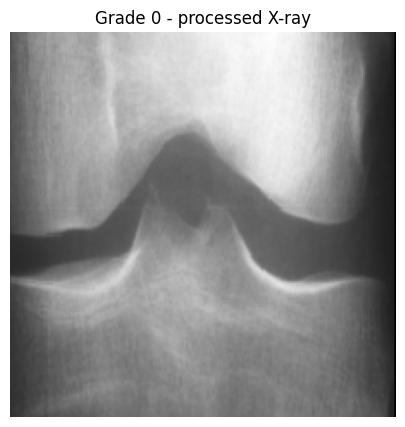

In [ ]:
# ============================================================
# CHECK PREPROCESSED IMAGE
# ============================================================

import matplotlib.pyplot as plt

img, label = tr_check[0]

print("Tensor shape:", img.shape)
print("Tensor dtype:", img.dtype)
print("Tensor min:", img.min().item())
print("Tensor max:", img.max().item())
print("Tensor mean:", img.mean().item())
print("Tensor std:", img.std().item())
print("Label:", tr_check.classes[label])

# Undo ImageNet normalization for visualization
display_img = img.clone()

for c in range(3):
    display_img[c] = (
        display_img[c] * STD[c] + MEAN[c]
    )

display_img = display_img.clamp(0, 1)

plt.figure(figsize=(7, 5))
plt.imshow(
    display_img[0].numpy(),
    cmap="gray"
)
plt.title(
    f"{tr_check.classes[label]} - processed X-ray"
)
plt.axis("off")
plt.show()

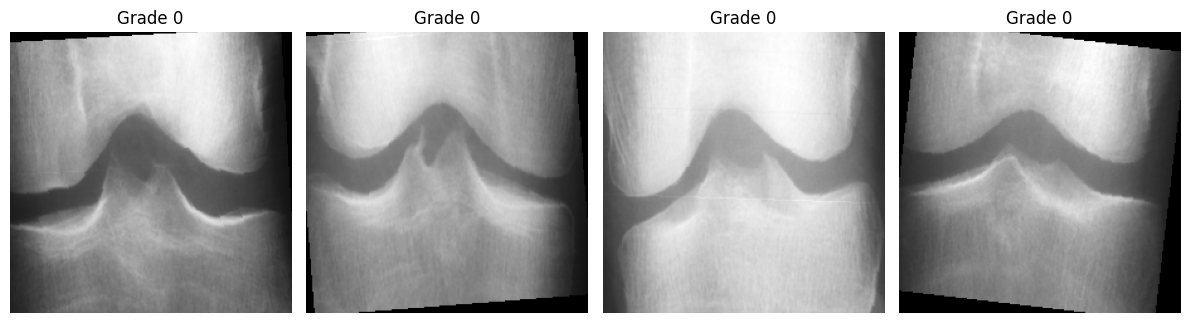

In [ ]:
# ============================================================
# AUGMENTATION CHECK
# ============================================================

raw_ds = ImageFolder(
    os.path.join(
        DATA_ROOT,
        "batch_1000",
        "train"
    ),
    loader=load_16bit_xray,
    transform=None
)

plt.figure(figsize=(12, 4))

for i in range(4):

    raw_img, label = raw_ds[i]

    aug_img = train_transform()(raw_img.clone())

    # Undo normalization
    show_img = aug_img.clone()

    for c in range(3):
        show_img[c] = (
            show_img[c] * STD[c] + MEAN[c]
        )

    show_img = show_img.clamp(0, 1)

    ax = plt.subplot(1, 4, i + 1)

    ax.imshow(
        show_img[0].numpy(),
        cmap="gray"
    )

    ax.set_title(
        raw_ds.classes[label]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# MODEL
# ============================================================

class SimpleCNN(nn.Module):

    def __init__(self, n):

        super().__init__()

        def blk(i, o):
            return nn.Sequential(
                nn.Conv2d(
                    i,
                    o,
                    3,
                    padding=1
                ),
                nn.BatchNorm2d(o),
                nn.ReLU(True),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            blk(3, 32),
            blk(32, 64),
            blk(64, 128),

            nn.Conv2d(
                128,
                256,
                3,
                padding=1
            ),

            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, n)
        )

    def forward(self, x):
        return self.classifier(
            self.features(x)
        )


def build_model(name, n=NUM_CLASSES):

    name = name.lower()

    if name == "resnet":

        model = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            n
        )

    elif name == "densenet":

        model = models.densenet201(
            weights=models.DenseNet201_Weights.DEFAULT
        )

        model.classifier = nn.Linear(
            model.classifier.in_features,
            n
        )

    elif name == "vit":

        model = models.vit_b_16(
            weights=models.ViT_B_16_Weights.DEFAULT
        )

        model.heads.head = nn.Linear(
            model.heads.head.in_features,
            n
        )

    elif name == "cnn":

        model = SimpleCNN(n)

    else:
        raise ValueError(name)

    return model

In [ ]:
# ============================================================
# TRAINING
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    total_loss = 0.0
    correct = 0
    n = 0

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        output = model(x)

        loss = criterion(
            output,
            y
        )

        loss.backward()
        optimizer.step()

        total_loss += (
            loss.item() * x.size(0)
        )

        correct += (
            output.argmax(1) == y
        ).sum().item()

        n += x.size(0)

    return (
        total_loss / n,
        correct / n
    )


@torch.no_grad()
def evaluate(model, loader):

    model.eval()

    ys = []
    ps = []

    for x, y in loader:

        output = model(
            x.to(device)
        )

        predictions = output.argmax(1)

        ps.extend(
            predictions.cpu().numpy()
        )

        ys.extend(
            y.numpy()
        )

    return (
        np.array(ys),
        np.array(ps)
    )

Device: cuda


In [ ]:
# ============================================================
# RUN ONE BATCH
# ============================================================

def run_batch(batch):

    print("\n" + "=" * 60)
    print(f"STARTING {MODEL_NAME.upper()} - BATCH {batch}")
    print("=" * 60)

    set_seed(SEED)

    # --------------------------------------------------------
    # Paths
    # --------------------------------------------------------

    bdir = os.path.join(
        DATA_ROOT,
        f"batch_{batch}"
    )

    train_dir = os.path.join(
        bdir,
        "train"
    )

    test_dir = os.path.join(
        bdir,
        "test"
    )

    # --------------------------------------------------------
    # Datasets
    # --------------------------------------------------------

    tr_ds = ImageFolder(
        train_dir,
        loader=load_16bit_xray,
        transform=train_transform()
    )

    te_ds = ImageFolder(
        test_dir,
        loader=load_16bit_xray,
        transform=eval_transform()
    )

    # --------------------------------------------------------
    # Class mapping check
    # --------------------------------------------------------

    print("\nClass mapping:")
    print(tr_ds.class_to_idx)

    if tr_ds.class_to_idx != te_ds.class_to_idx:
        raise ValueError(
            "TRAIN and TEST class mappings do not match!"
        )

    # --------------------------------------------------------
    # Original training class counts
    # --------------------------------------------------------

    train_labels = [
        label
        for _, label in tr_ds.samples
    ]

    counts = np.bincount(
        train_labels,
        minlength=NUM_CLASSES
    )

    print("\nTraining distribution:")

    for i, cls in enumerate(tr_ds.classes):
        print(
            f"{cls}: {counts[i]}"
        )

    # --------------------------------------------------------
    # Weighted sampler
    # --------------------------------------------------------

    sampler = make_weighted_sampler(
        train_labels
    )

    # --------------------------------------------------------
    # DataLoaders
    # --------------------------------------------------------

    train_loader = DataLoader(
        tr_ds,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        te_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = build_model(
        MODEL_NAME
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    history = []

    for epoch in range(
        1,
        EPOCHS + 1
    ):

        loss, acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "train_loss": float(loss),
            "train_accuracy": float(acc),
            "learning_rate": float(current_lr)
        })

        print(
            f"batch_{batch} "
            f"ep{epoch:02d} | "
            f"train_loss {loss:.3f} | "
            f"train_acc {acc:.3f} | "
            f"lr {current_lr:.7f}"
        )

    # --------------------------------------------------------
    # FROZEN TEST
    # Evaluate only after training is complete
    # --------------------------------------------------------

    print("\nEvaluating frozen test set...")

    yt, yp = evaluate(
        model,
        test_loader
    )

    res = compute_metrics(
        yt,
        yp
    )

    res.update({
        "model": MODEL_NAME,
        "batch": batch,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LR
    })

    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    outdir = os.path.join(
        DRIVE_OUT,
        MODEL_NAME
    )

    os.makedirs(
        outdir,
        exist_ok=True
    )

    # Metrics
    with open(
        os.path.join(
            outdir,
            f"batch_{batch}_metrics.json"
        ),
        "w"
    ) as f:

        json.dump(
            res,
            f,
            indent=2
        )

    # Confusion matrix
    cm = confusion_matrix(
        yt,
        yp,
        labels=list(
            range(NUM_CLASSES)
        )
    )

    np.savetxt(
        os.path.join(
            outdir,
            f"batch_{batch}_confusion.csv"
        ),
        cm,
        fmt="%d",
        delimiter=","
    )

    # Training history
    with open(
        os.path.join(
            outdir,
            f"batch_{batch}_history.json"
        ),
        "w"
    ) as f:

        json.dump(
            history,
            f,
            indent=2
        )

    # Checkpoint
    if SAVE_CHECKPOINTS:

        torch.save(
            model.state_dict(),
            os.path.join(
                outdir,
                f"batch_{batch}_final.pth"
            )
        )

    print("\n" + "-" * 60)
    print("FINAL TEST RESULTS")
    print("-" * 60)

    print(
        f"Accuracy : {res['accuracy']:.4f}"
    )

    print(
        f"Macro F1 : {res['macro_f1']:.4f}"
    )

    print(
        f"Weighted F1 : {res['weighted_f1']:.4f}"
    )

    print(
        f"Cohen Kappa : {res['cohen_kappa']:.4f}"
    )

    print(
        f"QWK : {res['quadratic_weighted_kappa']:.4f}"
    )

    print("\nConfusion Matrix:")
    print(cm)

    return res

In [ ]:
# ============================================================
# RUN BATCH 1000
# ============================================================

all_results = []

for b in BATCHES:

    print(
        f"\n===== {MODEL_NAME} batch_{b} ====="
    )

    result = run_batch(b)

    all_results.append(result)

print("\nBatch 1000 done.")


===== resnet batch_1000 =====

STARTING RESNET - BATCH 1000

Class mapping:
{'Grade 0': 0, 'Grade 1': 1, 'Grade 2': 2, 'Grade 3': 3, 'Grade 4': 4}

Training distribution:
Grade 0: 379
Grade 1: 85
Grade 2: 194
Grade 3: 47
Grade 4: 71
batch_1000 ep01 | train_loss 1.558 | train_acc 0.312 | lr 0.0000997
batch_1000 ep02 | train_loss 1.300 | train_acc 0.521 | lr 0.0000989
batch_1000 ep03 | train_loss 0.997 | train_acc 0.575 | lr 0.0000976
batch_1000 ep04 | train_loss 0.795 | train_acc 0.659 | lr 0.0000957
batch_1000 ep05 | train_loss 0.617 | train_acc 0.763 | lr 0.0000933
batch_1000 ep06 | train_loss 0.531 | train_acc 0.802 | lr 0.0000905
batch_1000 ep07 | train_loss 0.467 | train_acc 0.823 | lr 0.0000872
batch_1000 ep08 | train_loss 0.305 | train_acc 0.887 | lr 0.0000835
batch_1000 ep09 | train_loss 0.264 | train_acc 0.903 | lr 0.0000794
batch_1000 ep10 | train_loss 0.264 | train_acc 0.903 | lr 0.0000750
batch_1000 ep11 | train_loss 0.235 | train_acc 0.916 | lr 0.0000703
batch_1000 ep12 | 

RESNET — BATCH 1000
accuracy: 0.6666666666666666
weighted_precision: 0.6206059234364608
weighted_recall: 0.6666666666666666
weighted_f1: 0.6269717030831793
macro_precision: 0.4448553849692368
macro_recall: 0.47447841214209846
macro_f1: 0.41198113991251795
cohen_kappa: 0.41400259196490874
quadratic_weighted_kappa: 0.7028951115329853
model: resnet
batch: 1000
epochs: 30
batch_size: 32
learning_rate: 0.0001

Confusion Matrix:
[[462  11  34   0   1]
 [ 81   5  12   0   0]
 [ 86  15 140   8   6]
 [  1   0  29   7  25]
 [  0   0   2   2  12]]


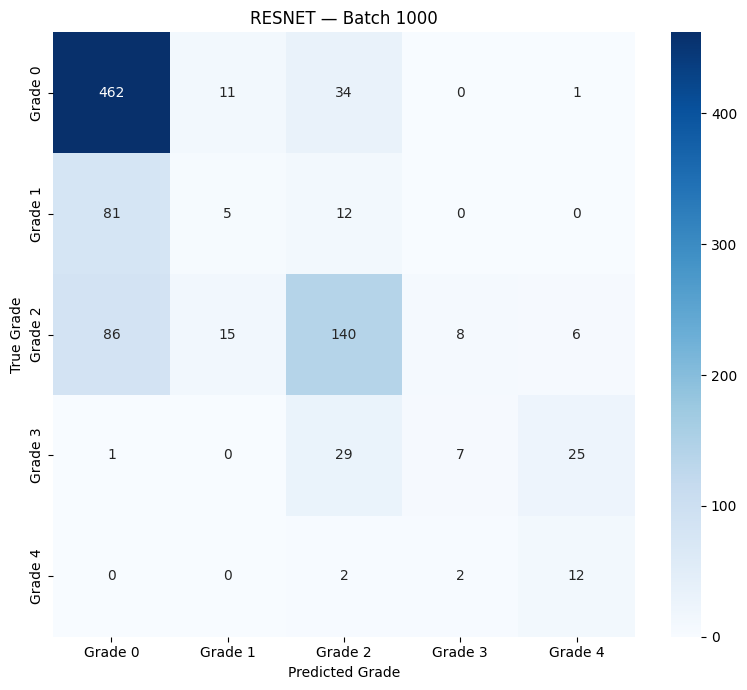


Confusion matrix graph saved to:
/content/drive/MyDrive/KL_Batches/runs/resnet/batch_1000_confusion_matrix.png

Results summary saved to:
/content/drive/MyDrive/KL_Batches/runs/resnet_batch_1000_summary.csv


In [ ]:
# ============================================================
# LOAD, PRINT, GRAPH AND SAVE RESULTS AUTOMATICALLY
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Automatically use the current model and batch
model_name = MODEL_NAME
batch = BATCHES[-1]

outdir = os.path.join(DRIVE_OUT, model_name)

metrics_path = os.path.join(
    outdir, f"batch_{batch}_metrics.json"
)

cm_path = os.path.join(
    outdir, f"batch_{batch}_confusion.csv"
)

# ------------------------------------------------------------
# LOAD SAVED METRICS
# ------------------------------------------------------------

with open(metrics_path, "r") as f:
    results = json.load(f)

print("=" * 60)
print(f"{model_name.upper()} — BATCH {batch}")
print("=" * 60)

for key, value in results.items():
    print(f"{key}: {value}")

# ------------------------------------------------------------
# LOAD SAVED CONFUSION MATRIX
# ------------------------------------------------------------

cm = np.loadtxt(cm_path, delimiter=",", dtype=int)

classes = [
    "Grade 0",
    "Grade 1",
    "Grade 2",
    "Grade 3",
    "Grade 4"
]

print("\nConfusion Matrix:")
print(cm)

# ------------------------------------------------------------
# GRAPHICAL CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(8, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title(f"{model_name.upper()} — Batch {batch}")
plt.xlabel("Predicted Grade")
plt.ylabel("True Grade")

plt.tight_layout()

graph_path = os.path.join(
    outdir,
    f"batch_{batch}_confusion_matrix.png"
)

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("\nConfusion matrix graph saved to:")
print(graph_path)

# ------------------------------------------------------------
# SAVE A CSV SUMMARY FOR COMPARING BATCHES
# ------------------------------------------------------------

summary_path = os.path.join(
    DRIVE_OUT,
    f"{model_name}_batch_{batch}_summary.csv"
)

pd.DataFrame([results]).to_csv(
    summary_path,
    index=False
)

print("\nResults summary saved to:")
print(summary_path)

## **For Batch 1500 Images**

In [ ]:
# ============================================================
# CONFIG
# ============================================================

MEMBER      = "Kalhara"
MODEL_NAME  = "resnet"

# Dataset is already available directly in Google Drive.
# We are NOT using dataset.zip here.
DRIVE_ZIP   = None

# Your batch folders are here:
# /content/drive/MyDrive/KL_Batches/batch_500
DRIVE_DATA  = "/content/drive/MyDrive/KL_Batches"

# Where results will be saved
DRIVE_OUT   = "/content/drive/MyDrive/KL_Batches/runs"

# Fast local disk
LOCAL_DATA  = "/content/data"

# ------------------------------------------------------------
# RUN ONE BATCH AT A TIME
# ------------------------------------------------------------
BATCHES     = [1500]

# ------------------------------------------------------------
# TRAINING
# ------------------------------------------------------------
EPOCHS      = 30
BATCH_SIZE  = 32

# Explicitly use 1e-4
LR          = 1e-4

# ------------------------------------------------------------
# SHARED POLICY
# ------------------------------------------------------------
IMAGE_SIZE  = 224
NUM_CLASSES = 5
SEED        = 42

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

SAVE_CHECKPOINTS = True

print("Model:", MODEL_NAME)
print("Batches:", BATCHES)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LR)

Model: resnet
Batches: [1500]
Epochs: 30
Batch size: 32
Learning rate: 0.0001


In [ ]:
# ============================================================
# DATA ROOT
# ============================================================

import os

DATA_ROOT = DRIVE_DATA

print("DATA_ROOT =", DATA_ROOT)

print("\nAvailable batches:")
print(sorted(
    d for d in os.listdir(DATA_ROOT)
    if d.startswith("batch_")
))

DATA_ROOT = /content/drive/MyDrive/KL_Batches

Available batches:
['batch_1500']


In [ ]:
# ============================================================
# IMPORTS + SEED
# ============================================================

import os
import json
import random
import copy

import numpy as np
import torch
import torch.nn as nn

from PIL import Image

from torch.utils.data import DataLoader, WeightedRandomSampler

from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    cohen_kappa_score,
    confusion_matrix
)

def set_seed(s=SEED):
    random.seed(s)
    np.random.seed(s)

    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
# ============================================================
# 16-BIT GRAYSCALE TIFF LOADER
# ============================================================

def load_16bit_xray(path):
    """
    Load a 16-bit grayscale TIFF.

    Original:
        uint16, approximately 0-65535

    Output:
        float32 tensor
        shape = [3, H, W]
        range approximately 0-1
    """

    img = Image.open(path)

    # Read the original 16-bit pixel values
    arr = np.array(img, dtype=np.uint16)

    # Convert to float32
    arr = arr.astype(np.float32)

    # Fixed scaling to the full uint16 range
    arr = arr / 65535.0

    # Convert to tensor: H,W -> 1,H,W
    tensor = torch.from_numpy(arr).unsqueeze(0)

    # Grayscale -> 3 identical channels
    tensor = tensor.repeat(3, 1, 1)

    return tensor

In [ ]:
# ============================================================
# TRANSFORMS
# ============================================================

def train_transform():
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

        # Moderate geometric augmentation
        transforms.RandomAffine(
            degrees=7,
            translate=(0.03, 0.03),
            scale=(0.95, 1.05)
        ),

        # Moderate intensity augmentation
        transforms.ColorJitter(
            brightness=0.10,
            contrast=0.10
        ),

        # ImageNet normalization for pretrained ResNet
        transforms.Normalize(MEAN, STD)
    ])


def eval_transform():
    # NO augmentation for frozen test
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.Normalize(MEAN, STD)
    ])

In [ ]:
# ============================================================
# DATASET CREATION
# ============================================================

def make_datasets(batch):

    bdir = os.path.join(DATA_ROOT, f"batch_{batch}")

    train_dir = os.path.join(bdir, "train")
    test_dir  = os.path.join(bdir, "test")

    tr_ds = ImageFolder(
        train_dir,
        loader=load_16bit_xray,
        transform=train_transform()
    )

    te_ds = ImageFolder(
        test_dir,
        loader=load_16bit_xray,
        transform=eval_transform()
    )

    return tr_ds, te_ds

In [ ]:
# ============================================================
# WEIGHTED OVERSAMPLING
# ============================================================

def make_weighted_sampler(labels):

    labels = np.asarray(labels)

    counts = np.bincount(
        labels,
        minlength=NUM_CLASSES
    )

    weights = (
        1.0 /
        np.maximum(counts, 1)
    )[labels]

    sampler = WeightedRandomSampler(
        torch.DoubleTensor(weights),
        num_samples=len(weights),
        replacement=True
    )

    return sampler

In [ ]:
# ============================================================
# METRICS
# ============================================================

def compute_metrics(yt, yp):

    wp, wr, wf, _ = precision_recall_fscore_support(
        yt,
        yp,
        average="weighted",
        zero_division=0
    )

    mp, mr, mf, _ = precision_recall_fscore_support(
        yt,
        yp,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": float(
            accuracy_score(yt, yp)
        ),

        "weighted_precision": float(wp),
        "weighted_recall": float(wr),
        "weighted_f1": float(wf),

        "macro_precision": float(mp),
        "macro_recall": float(mr),
        "macro_f1": float(mf),

        "cohen_kappa": float(
            cohen_kappa_score(yt, yp)
        ),

        "quadratic_weighted_kappa": float(
            cohen_kappa_score(
                yt,
                yp,
                weights="quadratic"
            )
        )
    }

In [ ]:
# ============================================================
# DATASET CHECK
# ============================================================

tr_check, te_check = make_datasets(1500)

print("TRAIN")
print("Total:", len(tr_check))
print("Classes:", tr_check.classes)
print("Mapping:", tr_check.class_to_idx)

for i, cls in enumerate(tr_check.classes):
    count = sum(
        label == i
        for _, label in tr_check.samples
    )
    print(f"{cls}: {count}")

print("\nTEST")
print("Total:", len(te_check))
print("Classes:", te_check.classes)
print("Mapping:", te_check.class_to_idx)

for i, cls in enumerate(te_check.classes):
    count = sum(
        label == i
        for _, label in te_check.samples
    )
    print(f"{cls}: {count}")

TRAIN
Total: 1177
Classes: ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Mapping: {'Grade 0': 0, 'Grade 1': 1, 'Grade 2': 2, 'Grade 3': 3, 'Grade 4': 4}
Grade 0: 594
Grade 1: 136
Grade 2: 304
Grade 3: 72
Grade 4: 71

TEST
Total: 939
Classes: ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Mapping: {'Grade 0': 0, 'Grade 1': 1, 'Grade 2': 2, 'Grade 3': 3, 'Grade 4': 4}
Grade 0: 508
Grade 1: 98
Grade 2: 255
Grade 3: 62
Grade 4: 16


Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Tensor min: -2.0469346046447754
Tensor max: 0.24031294882297516
Tensor mean: -1.1307451725006104
Tensor std: 0.48534512519836426
Label: Grade 0


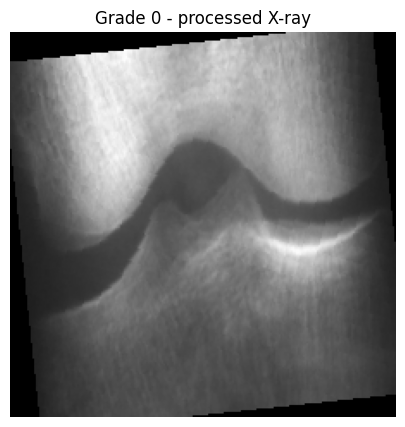

In [ ]:
# ============================================================
# CHECK PREPROCESSED IMAGE
# ============================================================

import matplotlib.pyplot as plt

img, label = tr_check[0]

print("Tensor shape:", img.shape)
print("Tensor dtype:", img.dtype)
print("Tensor min:", img.min().item())
print("Tensor max:", img.max().item())
print("Tensor mean:", img.mean().item())
print("Tensor std:", img.std().item())
print("Label:", tr_check.classes[label])

# Undo ImageNet normalization for visualization
display_img = img.clone()

for c in range(3):
    display_img[c] = (
        display_img[c] * STD[c] + MEAN[c]
    )

display_img = display_img.clamp(0, 1)

plt.figure(figsize=(7, 5))
plt.imshow(
    display_img[0].numpy(),
    cmap="gray"
)
plt.title(
    f"{tr_check.classes[label]} - processed X-ray"
)
plt.axis("off")
plt.show()

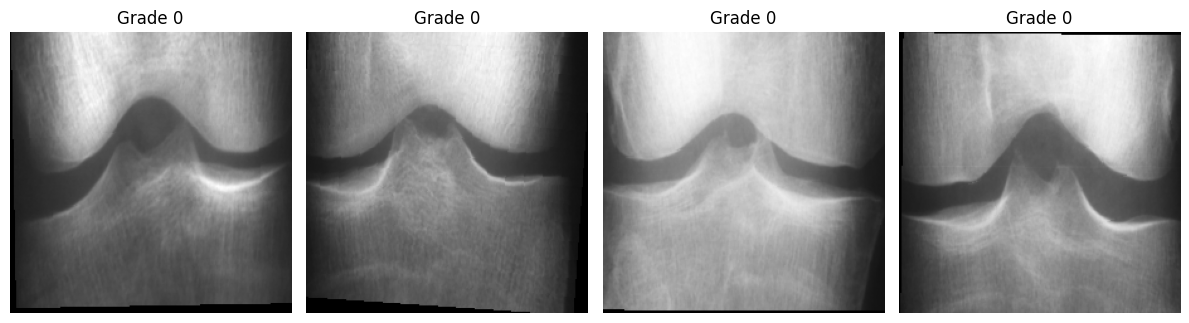

In [ ]:
# ============================================================
# AUGMENTATION CHECK
# ============================================================

raw_ds = ImageFolder(
    os.path.join(
        DATA_ROOT,
        "batch_1500",
        "train"
    ),
    loader=load_16bit_xray,
    transform=None
)

plt.figure(figsize=(12, 4))

for i in range(4):

    raw_img, label = raw_ds[i]

    aug_img = train_transform()(raw_img.clone())

    # Undo normalization
    show_img = aug_img.clone()

    for c in range(3):
        show_img[c] = (
            show_img[c] * STD[c] + MEAN[c]
        )

    show_img = show_img.clamp(0, 1)

    ax = plt.subplot(1, 4, i + 1)

    ax.imshow(
        show_img[0].numpy(),
        cmap="gray"
    )

    ax.set_title(
        raw_ds.classes[label]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# MODEL
# ============================================================

class SimpleCNN(nn.Module):

    def __init__(self, n):

        super().__init__()

        def blk(i, o):
            return nn.Sequential(
                nn.Conv2d(
                    i,
                    o,
                    3,
                    padding=1
                ),
                nn.BatchNorm2d(o),
                nn.ReLU(True),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            blk(3, 32),
            blk(32, 64),
            blk(64, 128),

            nn.Conv2d(
                128,
                256,
                3,
                padding=1
            ),

            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, n)
        )

    def forward(self, x):
        return self.classifier(
            self.features(x)
        )


def build_model(name, n=NUM_CLASSES):

    name = name.lower()

    if name == "resnet":

        model = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            n
        )

    elif name == "densenet":

        model = models.densenet201(
            weights=models.DenseNet201_Weights.DEFAULT
        )

        model.classifier = nn.Linear(
            model.classifier.in_features,
            n
        )

    elif name == "vit":

        model = models.vit_b_16(
            weights=models.ViT_B_16_Weights.DEFAULT
        )

        model.heads.head = nn.Linear(
            model.heads.head.in_features,
            n
        )

    elif name == "cnn":

        model = SimpleCNN(n)

    else:
        raise ValueError(name)

    return model

In [ ]:
# ============================================================
# TRAINING
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    total_loss = 0.0
    correct = 0
    n = 0

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        output = model(x)

        loss = criterion(
            output,
            y
        )

        loss.backward()
        optimizer.step()

        total_loss += (
            loss.item() * x.size(0)
        )

        correct += (
            output.argmax(1) == y
        ).sum().item()

        n += x.size(0)

    return (
        total_loss / n,
        correct / n
    )


@torch.no_grad()
def evaluate(model, loader):

    model.eval()

    ys = []
    ps = []

    for x, y in loader:

        output = model(
            x.to(device)
        )

        predictions = output.argmax(1)

        ps.extend(
            predictions.cpu().numpy()
        )

        ys.extend(
            y.numpy()
        )

    return (
        np.array(ys),
        np.array(ps)
    )

Device: cuda


In [ ]:
# ============================================================
# RUN ONE BATCH
# ============================================================

def run_batch(batch):

    print("\n" + "=" * 60)
    print(f"STARTING {MODEL_NAME.upper()} - BATCH {batch}")
    print("=" * 60)

    set_seed(SEED)

    # --------------------------------------------------------
    # Paths
    # --------------------------------------------------------

    bdir = os.path.join(
        DATA_ROOT,
        f"batch_{batch}"
    )

    train_dir = os.path.join(
        bdir,
        "train"
    )

    test_dir = os.path.join(
        bdir,
        "test"
    )

    # --------------------------------------------------------
    # Datasets
    # --------------------------------------------------------

    tr_ds = ImageFolder(
        train_dir,
        loader=load_16bit_xray,
        transform=train_transform()
    )

    te_ds = ImageFolder(
        test_dir,
        loader=load_16bit_xray,
        transform=eval_transform()
    )

    # --------------------------------------------------------
    # Class mapping check
    # --------------------------------------------------------

    print("\nClass mapping:")
    print(tr_ds.class_to_idx)

    if tr_ds.class_to_idx != te_ds.class_to_idx:
        raise ValueError(
            "TRAIN and TEST class mappings do not match!"
        )

    # --------------------------------------------------------
    # Original training class counts
    # --------------------------------------------------------

    train_labels = [
        label
        for _, label in tr_ds.samples
    ]

    counts = np.bincount(
        train_labels,
        minlength=NUM_CLASSES
    )

    print("\nTraining distribution:")

    for i, cls in enumerate(tr_ds.classes):
        print(
            f"{cls}: {counts[i]}"
        )

    # --------------------------------------------------------
    # Weighted sampler
    # --------------------------------------------------------

    sampler = make_weighted_sampler(
        train_labels
    )

    # --------------------------------------------------------
    # DataLoaders
    # --------------------------------------------------------

    train_loader = DataLoader(
        tr_ds,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        te_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = build_model(
        MODEL_NAME
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    history = []

    for epoch in range(
        1,
        EPOCHS + 1
    ):

        loss, acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "train_loss": float(loss),
            "train_accuracy": float(acc),
            "learning_rate": float(current_lr)
        })

        print(
            f"batch_{batch} "
            f"ep{epoch:02d} | "
            f"train_loss {loss:.3f} | "
            f"train_acc {acc:.3f} | "
            f"lr {current_lr:.7f}"
        )

    # --------------------------------------------------------
    # FROZEN TEST
    # Evaluate only after training is complete
    # --------------------------------------------------------

    print("\nEvaluating frozen test set...")

    yt, yp = evaluate(
        model,
        test_loader
    )

    res = compute_metrics(
        yt,
        yp
    )

    res.update({
        "model": MODEL_NAME,
        "batch": batch,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LR
    })

    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    outdir = os.path.join(
        DRIVE_OUT,
        MODEL_NAME
    )

    os.makedirs(
        outdir,
        exist_ok=True
    )

    # Metrics
    with open(
        os.path.join(
            outdir,
            f"batch_{batch}_metrics.json"
        ),
        "w"
    ) as f:

        json.dump(
            res,
            f,
            indent=2
        )

    # Confusion matrix
    cm = confusion_matrix(
        yt,
        yp,
        labels=list(
            range(NUM_CLASSES)
        )
    )

    np.savetxt(
        os.path.join(
            outdir,
            f"batch_{batch}_confusion.csv"
        ),
        cm,
        fmt="%d",
        delimiter=","
    )

    # Training history
    with open(
        os.path.join(
            outdir,
            f"batch_{batch}_history.json"
        ),
        "w"
    ) as f:

        json.dump(
            history,
            f,
            indent=2
        )

    # Checkpoint
    if SAVE_CHECKPOINTS:

        torch.save(
            model.state_dict(),
            os.path.join(
                outdir,
                f"batch_{batch}_final.pth"
            )
        )

    print("\n" + "-" * 60)
    print("FINAL TEST RESULTS")
    print("-" * 60)

    print(
        f"Accuracy : {res['accuracy']:.4f}"
    )

    print(
        f"Macro F1 : {res['macro_f1']:.4f}"
    )

    print(
        f"Weighted F1 : {res['weighted_f1']:.4f}"
    )

    print(
        f"Cohen Kappa : {res['cohen_kappa']:.4f}"
    )

    print(
        f"QWK : {res['quadratic_weighted_kappa']:.4f}"
    )

    print("\nConfusion Matrix:")
    print(cm)

    return res

In [ ]:
# ============================================================
# RUN BATCH 1500
# ============================================================

all_results = []

for b in BATCHES:

    print(
        f"\n===== {MODEL_NAME} batch_{b} ====="
    )

    result = run_batch(b)

    all_results.append(result)

print("\nBatch 1500 done.")


===== resnet batch_1500 =====

STARTING RESNET - BATCH 1500

Class mapping:
{'Grade 0': 0, 'Grade 1': 1, 'Grade 2': 2, 'Grade 3': 3, 'Grade 4': 4}

Training distribution:
Grade 0: 594
Grade 1: 136
Grade 2: 304
Grade 3: 72
Grade 4: 71
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s]


batch_1500 ep01 | train_loss 1.513 | train_acc 0.358 | lr 0.0000997
batch_1500 ep02 | train_loss 1.114 | train_acc 0.539 | lr 0.0000989
batch_1500 ep03 | train_loss 0.800 | train_acc 0.679 | lr 0.0000976
batch_1500 ep04 | train_loss 0.656 | train_acc 0.734 | lr 0.0000957
batch_1500 ep05 | train_loss 0.522 | train_acc 0.789 | lr 0.0000933
batch_1500 ep06 | train_loss 0.419 | train_acc 0.842 | lr 0.0000905
batch_1500 ep07 | train_loss 0.394 | train_acc 0.853 | lr 0.0000872
batch_1500 ep08 | train_loss 0.329 | train_acc 0.877 | lr 0.0000835
batch_1500 ep09 | train_loss 0.248 | train_acc 0.899 | lr 0.0000794
batch_1500 ep10 | train_loss 0.224 | train_acc 0.917 | lr 0.0000750
batch_1500 ep11 | train_loss 0.163 | train_acc 0.937 | lr 0.0000703
batch_1500 ep12 | train_loss 0.140 | train_acc 0.957 | lr 0.0000655
batch_1500 ep13 | train_loss 0.140 | train_acc 0.948 | lr 0.0000604
batch_1500 ep14 | train_loss 0.126 | train_acc 0.951 | lr 0.0000552
batch_1500 ep15 | train_loss 0.102 | train_acc 0

RESNET — BATCH 1500
accuracy: 0.6528221512247071
weighted_precision: 0.606307585951072
weighted_recall: 0.6528221512247071
weighted_f1: 0.6214697896203807
macro_precision: 0.4388409966154054
macro_recall: 0.4845233414676514
macro_f1: 0.4322457665892584
cohen_kappa: 0.4046594305918322
quadratic_weighted_kappa: 0.6922623553656885
model: resnet
batch: 1500
epochs: 30
batch_size: 32
learning_rate: 0.0001

Confusion Matrix:
[[435  20  53   0   0]
 [ 71   3  24   0   0]
 [ 75  11 151  13   5]
 [  1   0  30  12  19]
 [  0   0   2   2  12]]


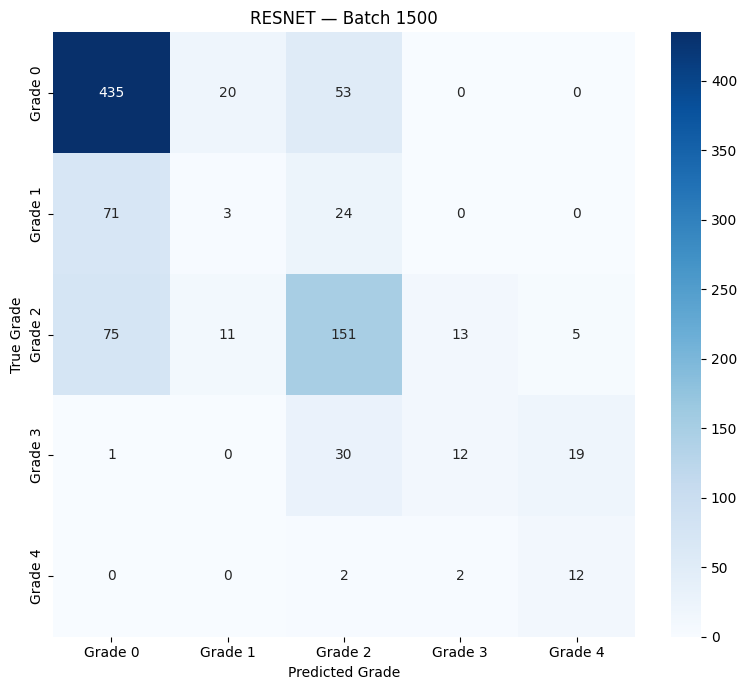


Confusion matrix graph saved to:
/content/drive/MyDrive/KL_Batches/runs/resnet/batch_1500_confusion_matrix.png

Results summary saved to:
/content/drive/MyDrive/KL_Batches/runs/resnet_batch_1500_summary.csv


In [ ]:
# ============================================================
# LOAD, PRINT, GRAPH AND SAVE RESULTS AUTOMATICALLY
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Automatically use the current model and batch
model_name = MODEL_NAME
batch = BATCHES[-1]

outdir = os.path.join(DRIVE_OUT, model_name)

metrics_path = os.path.join(
    outdir, f"batch_{batch}_metrics.json"
)

cm_path = os.path.join(
    outdir, f"batch_{batch}_confusion.csv"
)

# ------------------------------------------------------------
# LOAD SAVED METRICS
# ------------------------------------------------------------

with open(metrics_path, "r") as f:
    results = json.load(f)

print("=" * 60)
print(f"{model_name.upper()} — BATCH {batch}")
print("=" * 60)

for key, value in results.items():
    print(f"{key}: {value}")

# ------------------------------------------------------------
# LOAD SAVED CONFUSION MATRIX
# ------------------------------------------------------------

cm = np.loadtxt(cm_path, delimiter=",", dtype=int)

classes = [
    "Grade 0",
    "Grade 1",
    "Grade 2",
    "Grade 3",
    "Grade 4"
]

print("\nConfusion Matrix:")
print(cm)

# ------------------------------------------------------------
# GRAPHICAL CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(8, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title(f"{model_name.upper()} — Batch {batch}")
plt.xlabel("Predicted Grade")
plt.ylabel("True Grade")

plt.tight_layout()

graph_path = os.path.join(
    outdir,
    f"batch_{batch}_confusion_matrix.png"
)

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("\nConfusion matrix graph saved to:")
print(graph_path)

# ------------------------------------------------------------
# SAVE A CSV SUMMARY FOR COMPARING BATCHES
# ------------------------------------------------------------

summary_path = os.path.join(
    DRIVE_OUT,
    f"{model_name}_batch_{batch}_summary.csv"
)

pd.DataFrame([results]).to_csv(
    summary_path,
    index=False
)

print("\nResults summary saved to:")
print(summary_path)

## **For Batch 2000 Images**

In [ ]:
# ============================================================
# CONFIG
# ============================================================

MEMBER      = "Kalhara"
MODEL_NAME  = "resnet"

# Dataset is already available directly in Google Drive.
# We are NOT using dataset.zip here.
DRIVE_ZIP   = None

# Your batch folders are here:
# /content/drive/MyDrive/KL_Batches/batch_500
DRIVE_DATA  = "/content/drive/MyDrive/KL_Batches"

# Where results will be saved
DRIVE_OUT   = "/content/drive/MyDrive/KL_Batches/runs"

# Fast local disk
LOCAL_DATA  = "/content/data"

# ------------------------------------------------------------
# RUN ONE BATCH AT A TIME
# ------------------------------------------------------------
BATCHES     = [2000]

# ------------------------------------------------------------
# TRAINING
# ------------------------------------------------------------
EPOCHS      = 30
BATCH_SIZE  = 32

# Explicitly use 1e-4
LR          = 1e-4

# ------------------------------------------------------------
# SHARED POLICY
# ------------------------------------------------------------
IMAGE_SIZE  = 224
NUM_CLASSES = 5
SEED        = 42

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

SAVE_CHECKPOINTS = True

print("Model:", MODEL_NAME)
print("Batches:", BATCHES)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LR)

Model: resnet
Batches: [2000]
Epochs: 30
Batch size: 32
Learning rate: 0.0001


In [ ]:
# ============================================================
# DATA ROOT
# ============================================================

import os

DATA_ROOT = DRIVE_DATA

print("DATA_ROOT =", DATA_ROOT)

print("\nAvailable batches:")
print(sorted(
    d for d in os.listdir(DATA_ROOT)
    if d.startswith("batch_")
))

DATA_ROOT = /content/drive/MyDrive/KL_Batches

Available batches:
['batch_2000', 'batch_3000']


In [ ]:
# ============================================================
# IMPORTS + SEED
# ============================================================

import os
import json
import random
import copy

import numpy as np
import torch
import torch.nn as nn

from PIL import Image

from torch.utils.data import DataLoader, WeightedRandomSampler

from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    cohen_kappa_score,
    confusion_matrix
)

def set_seed(s=SEED):
    random.seed(s)
    np.random.seed(s)

    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
# ============================================================
# 16-BIT GRAYSCALE TIFF LOADER
# ============================================================

def load_16bit_xray(path):
    """
    Load a 16-bit grayscale TIFF.

    Original:
        uint16, approximately 0-65535

    Output:
        float32 tensor
        shape = [3, H, W]
        range approximately 0-1
    """

    img = Image.open(path)

    # Read the original 16-bit pixel values
    arr = np.array(img, dtype=np.uint16)

    # Convert to float32
    arr = arr.astype(np.float32)

    # Fixed scaling to the full uint16 range
    arr = arr / 65535.0

    # Convert to tensor: H,W -> 1,H,W
    tensor = torch.from_numpy(arr).unsqueeze(0)

    # Grayscale -> 3 identical channels
    tensor = tensor.repeat(3, 1, 1)

    return tensor

In [ ]:
# ============================================================
# TRANSFORMS
# ============================================================

def train_transform():
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

        # Moderate geometric augmentation
        transforms.RandomAffine(
            degrees=7,
            translate=(0.03, 0.03),
            scale=(0.95, 1.05)
        ),

        # Moderate intensity augmentation
        transforms.ColorJitter(
            brightness=0.10,
            contrast=0.10
        ),

        # ImageNet normalization for pretrained ResNet
        transforms.Normalize(MEAN, STD)
    ])


def eval_transform():
    # NO augmentation for frozen test
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.Normalize(MEAN, STD)
    ])

In [ ]:
# ============================================================
# DATASET CREATION
# ============================================================

def make_datasets(batch):

    bdir = os.path.join(DATA_ROOT, f"batch_{batch}")

    train_dir = os.path.join(bdir, "train")
    test_dir  = os.path.join(bdir, "test")

    tr_ds = ImageFolder(
        train_dir,
        loader=load_16bit_xray,
        transform=train_transform()
    )

    te_ds = ImageFolder(
        test_dir,
        loader=load_16bit_xray,
        transform=eval_transform()
    )

    return tr_ds, te_ds

In [ ]:
# ============================================================
# WEIGHTED OVERSAMPLING
# ============================================================

def make_weighted_sampler(labels):

    labels = np.asarray(labels)

    counts = np.bincount(
        labels,
        minlength=NUM_CLASSES
    )

    weights = (
        1.0 /
        np.maximum(counts, 1)
    )[labels]

    sampler = WeightedRandomSampler(
        torch.DoubleTensor(weights),
        num_samples=len(weights),
        replacement=True
    )

    return sampler

In [ ]:
# ============================================================
# METRICS
# ============================================================

def compute_metrics(yt, yp):

    wp, wr, wf, _ = precision_recall_fscore_support(
        yt,
        yp,
        average="weighted",
        zero_division=0
    )

    mp, mr, mf, _ = precision_recall_fscore_support(
        yt,
        yp,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": float(
            accuracy_score(yt, yp)
        ),

        "weighted_precision": float(wp),
        "weighted_recall": float(wr),
        "weighted_f1": float(wf),

        "macro_precision": float(mp),
        "macro_recall": float(mr),
        "macro_f1": float(mf),

        "cohen_kappa": float(
            cohen_kappa_score(yt, yp)
        ),

        "quadratic_weighted_kappa": float(
            cohen_kappa_score(
                yt,
                yp,
                weights="quadratic"
            )
        )
    }

In [ ]:
# ============================================================
# DATASET CHECK
# ============================================================

tr_check, te_check = make_datasets(2000)

print("TRAIN")
print("Total:", len(tr_check))
print("Classes:", tr_check.classes)
print("Mapping:", tr_check.class_to_idx)

for i, cls in enumerate(tr_check.classes):
    count = sum(
        label == i
        for _, label in tr_check.samples
    )
    print(f"{cls}: {count}")

print("\nTEST")
print("Total:", len(te_check))
print("Classes:", te_check.classes)
print("Mapping:", te_check.class_to_idx)

for i, cls in enumerate(te_check.classes):
    count = sum(
        label == i
        for _, label in te_check.samples
    )
    print(f"{cls}: {count}")

TRAIN
Total: 1590
Classes: ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Mapping: {'Grade 0': 0, 'Grade 1': 1, 'Grade 2': 2, 'Grade 3': 3, 'Grade 4': 4}
Grade 0: 821
Grade 1: 187
Grade 2: 415
Grade 3: 96
Grade 4: 71

TEST
Total: 939
Classes: ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Mapping: {'Grade 0': 0, 'Grade 1': 1, 'Grade 2': 2, 'Grade 3': 3, 'Grade 4': 4}
Grade 0: 508
Grade 1: 98
Grade 2: 255
Grade 3: 62
Grade 4: 16


Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Tensor min: -2.1179039478302
Tensor max: 0.31439346075057983
Tensor mean: -1.0990527868270874
Tensor std: 0.43701210618019104
Label: Grade 0


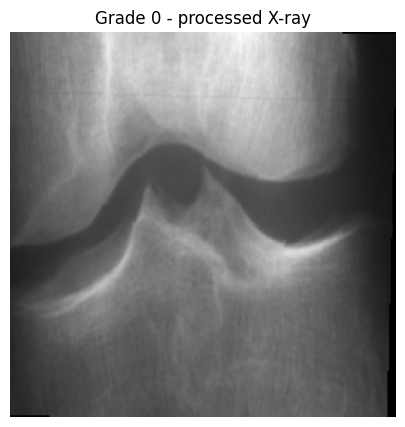

In [ ]:
# ============================================================
# CHECK PREPROCESSED IMAGE
# ============================================================

import matplotlib.pyplot as plt

img, label = tr_check[0]

print("Tensor shape:", img.shape)
print("Tensor dtype:", img.dtype)
print("Tensor min:", img.min().item())
print("Tensor max:", img.max().item())
print("Tensor mean:", img.mean().item())
print("Tensor std:", img.std().item())
print("Label:", tr_check.classes[label])

# Undo ImageNet normalization for visualization
display_img = img.clone()

for c in range(3):
    display_img[c] = (
        display_img[c] * STD[c] + MEAN[c]
    )

display_img = display_img.clamp(0, 1)

plt.figure(figsize=(7, 5))
plt.imshow(
    display_img[0].numpy(),
    cmap="gray"
)
plt.title(
    f"{tr_check.classes[label]} - processed X-ray"
)
plt.axis("off")
plt.show()

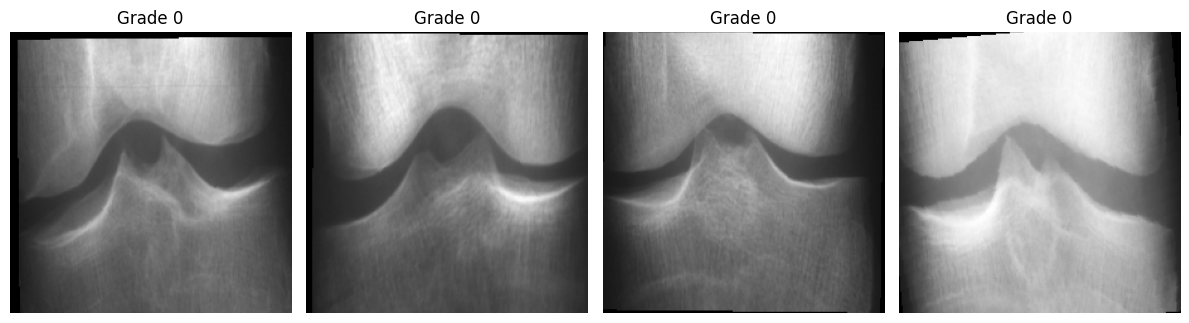

In [ ]:
# ============================================================
# AUGMENTATION CHECK
# ============================================================

raw_ds = ImageFolder(
    os.path.join(
        DATA_ROOT,
        "batch_2000",
        "train"
    ),
    loader=load_16bit_xray,
    transform=None
)

plt.figure(figsize=(12, 4))

for i in range(4):

    raw_img, label = raw_ds[i]

    aug_img = train_transform()(raw_img.clone())

    # Undo normalization
    show_img = aug_img.clone()

    for c in range(3):
        show_img[c] = (
            show_img[c] * STD[c] + MEAN[c]
        )

    show_img = show_img.clamp(0, 1)

    ax = plt.subplot(1, 4, i + 1)

    ax.imshow(
        show_img[0].numpy(),
        cmap="gray"
    )

    ax.set_title(
        raw_ds.classes[label]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# MODEL
# ============================================================

class SimpleCNN(nn.Module):

    def __init__(self, n):

        super().__init__()

        def blk(i, o):
            return nn.Sequential(
                nn.Conv2d(
                    i,
                    o,
                    3,
                    padding=1
                ),
                nn.BatchNorm2d(o),
                nn.ReLU(True),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            blk(3, 32),
            blk(32, 64),
            blk(64, 128),

            nn.Conv2d(
                128,
                256,
                3,
                padding=1
            ),

            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, n)
        )

    def forward(self, x):
        return self.classifier(
            self.features(x)
        )


def build_model(name, n=NUM_CLASSES):

    name = name.lower()

    if name == "resnet":

        model = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            n
        )

    elif name == "densenet":

        model = models.densenet201(
            weights=models.DenseNet201_Weights.DEFAULT
        )

        model.classifier = nn.Linear(
            model.classifier.in_features,
            n
        )

    elif name == "vit":

        model = models.vit_b_16(
            weights=models.ViT_B_16_Weights.DEFAULT
        )

        model.heads.head = nn.Linear(
            model.heads.head.in_features,
            n
        )

    elif name == "cnn":

        model = SimpleCNN(n)

    else:
        raise ValueError(name)

    return model

In [ ]:
# ============================================================
# TRAINING
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    total_loss = 0.0
    correct = 0
    n = 0

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        output = model(x)

        loss = criterion(
            output,
            y
        )

        loss.backward()
        optimizer.step()

        total_loss += (
            loss.item() * x.size(0)
        )

        correct += (
            output.argmax(1) == y
        ).sum().item()

        n += x.size(0)

    return (
        total_loss / n,
        correct / n
    )


@torch.no_grad()
def evaluate(model, loader):

    model.eval()

    ys = []
    ps = []

    for x, y in loader:

        output = model(
            x.to(device)
        )

        predictions = output.argmax(1)

        ps.extend(
            predictions.cpu().numpy()
        )

        ys.extend(
            y.numpy()
        )

    return (
        np.array(ys),
        np.array(ps)
    )

Device: cuda


In [ ]:
# ============================================================
# RUN ONE BATCH
# ============================================================

def run_batch(batch):

    print("\n" + "=" * 60)
    print(f"STARTING {MODEL_NAME.upper()} - BATCH {batch}")
    print("=" * 60)

    set_seed(SEED)

    # --------------------------------------------------------
    # Paths
    # --------------------------------------------------------

    bdir = os.path.join(
        DATA_ROOT,
        f"batch_{batch}"
    )

    train_dir = os.path.join(
        bdir,
        "train"
    )

    test_dir = os.path.join(
        bdir,
        "test"
    )

    # --------------------------------------------------------
    # Datasets
    # --------------------------------------------------------

    tr_ds = ImageFolder(
        train_dir,
        loader=load_16bit_xray,
        transform=train_transform()
    )

    te_ds = ImageFolder(
        test_dir,
        loader=load_16bit_xray,
        transform=eval_transform()
    )

    # --------------------------------------------------------
    # Class mapping check
    # --------------------------------------------------------

    print("\nClass mapping:")
    print(tr_ds.class_to_idx)

    if tr_ds.class_to_idx != te_ds.class_to_idx:
        raise ValueError(
            "TRAIN and TEST class mappings do not match!"
        )

    # --------------------------------------------------------
    # Original training class counts
    # --------------------------------------------------------

    train_labels = [
        label
        for _, label in tr_ds.samples
    ]

    counts = np.bincount(
        train_labels,
        minlength=NUM_CLASSES
    )

    print("\nTraining distribution:")

    for i, cls in enumerate(tr_ds.classes):
        print(
            f"{cls}: {counts[i]}"
        )

    # --------------------------------------------------------
    # Weighted sampler
    # --------------------------------------------------------

    sampler = make_weighted_sampler(
        train_labels
    )

    # --------------------------------------------------------
    # DataLoaders
    # --------------------------------------------------------

    train_loader = DataLoader(
        tr_ds,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        te_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = build_model(
        MODEL_NAME
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    history = []

    for epoch in range(
        1,
        EPOCHS + 1
    ):

        loss, acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "train_loss": float(loss),
            "train_accuracy": float(acc),
            "learning_rate": float(current_lr)
        })

        print(
            f"batch_{batch} "
            f"ep{epoch:02d} | "
            f"train_loss {loss:.3f} | "
            f"train_acc {acc:.3f} | "
            f"lr {current_lr:.7f}"
        )

    # --------------------------------------------------------
    # FROZEN TEST
    # Evaluate only after training is complete
    # --------------------------------------------------------

    print("\nEvaluating frozen test set...")

    yt, yp = evaluate(
        model,
        test_loader
    )

    res = compute_metrics(
        yt,
        yp
    )

    res.update({
        "model": MODEL_NAME,
        "batch": batch,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LR
    })

    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    outdir = os.path.join(
        DRIVE_OUT,
        MODEL_NAME
    )

    os.makedirs(
        outdir,
        exist_ok=True
    )

    # Metrics
    with open(
        os.path.join(
            outdir,
            f"batch_{batch}_metrics.json"
        ),
        "w"
    ) as f:

        json.dump(
            res,
            f,
            indent=2
        )

    # Confusion matrix
    cm = confusion_matrix(
        yt,
        yp,
        labels=list(
            range(NUM_CLASSES)
        )
    )

    np.savetxt(
        os.path.join(
            outdir,
            f"batch_{batch}_confusion.csv"
        ),
        cm,
        fmt="%d",
        delimiter=","
    )

    # Training history
    with open(
        os.path.join(
            outdir,
            f"batch_{batch}_history.json"
        ),
        "w"
    ) as f:

        json.dump(
            history,
            f,
            indent=2
        )

    # Checkpoint
    if SAVE_CHECKPOINTS:

        torch.save(
            model.state_dict(),
            os.path.join(
                outdir,
                f"batch_{batch}_final.pth"
            )
        )

    print("\n" + "-" * 60)
    print("FINAL TEST RESULTS")
    print("-" * 60)

    print(
        f"Accuracy : {res['accuracy']:.4f}"
    )

    print(
        f"Macro F1 : {res['macro_f1']:.4f}"
    )

    print(
        f"Weighted F1 : {res['weighted_f1']:.4f}"
    )

    print(
        f"Cohen Kappa : {res['cohen_kappa']:.4f}"
    )

    print(
        f"QWK : {res['quadratic_weighted_kappa']:.4f}"
    )

    print("\nConfusion Matrix:")
    print(cm)

    return res

In [ ]:
# ============================================================
# RUN BATCH 2000
# ============================================================

all_results = []

for b in BATCHES:

    print(
        f"\n===== {MODEL_NAME} batch_{b} ====="
    )

    result = run_batch(b)

    all_results.append(result)

print("\nBatch 2000 done.")


===== resnet batch_2000 =====

STARTING RESNET - BATCH 2000

Class mapping:
{'Grade 0': 0, 'Grade 1': 1, 'Grade 2': 2, 'Grade 3': 3, 'Grade 4': 4}

Training distribution:
Grade 0: 821
Grade 1: 187
Grade 2: 415
Grade 3: 96
Grade 4: 71
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


batch_2000 ep01 | train_loss 1.464 | train_acc 0.359 | lr 0.0000997
batch_2000 ep02 | train_loss 0.986 | train_acc 0.579 | lr 0.0000989
batch_2000 ep03 | train_loss 0.704 | train_acc 0.709 | lr 0.0000976
batch_2000 ep04 | train_loss 0.556 | train_acc 0.775 | lr 0.0000957
batch_2000 ep05 | train_loss 0.486 | train_acc 0.807 | lr 0.0000933
batch_2000 ep06 | train_loss 0.431 | train_acc 0.835 | lr 0.0000905
batch_2000 ep07 | train_loss 0.354 | train_acc 0.870 | lr 0.0000872
batch_2000 ep08 | train_loss 0.284 | train_acc 0.900 | lr 0.0000835
batch_2000 ep09 | train_loss 0.217 | train_acc 0.921 | lr 0.0000794
batch_2000 ep10 | train_loss 0.228 | train_acc 0.917 | lr 0.0000750
batch_2000 ep11 | train_loss 0.165 | train_acc 0.945 | lr 0.0000703
batch_2000 ep12 | train_loss 0.133 | train_acc 0.950 | lr 0.0000655
batch_2000 ep13 | train_loss 0.117 | train_acc 0.962 | lr 0.0000604
batch_2000 ep14 | train_loss 0.132 | train_acc 0.950 | lr 0.0000552
batch_2000 ep15 | train_loss 0.128 | train_acc 0

RESNET — BATCH 2000
accuracy: 0.6560170394036209
weighted_precision: 0.6175940228710314
weighted_recall: 0.6560170394036209
weighted_f1: 0.6312292522472142
macro_precision: 0.4705261974072374
macro_recall: 0.5185728848308437
macro_f1: 0.47483565595692384
cohen_kappa: 0.41468229845129534
quadratic_weighted_kappa: 0.6985894649957327
model: resnet
batch: 2000
epochs: 30
batch_size: 32
learning_rate: 0.0001

Confusion Matrix:
[[431  23  53   1   0]
 [ 76   6  15   1   0]
 [ 70  14 148  18   5]
 [  0   0  31  18  13]
 [  0   0   1   2  13]]


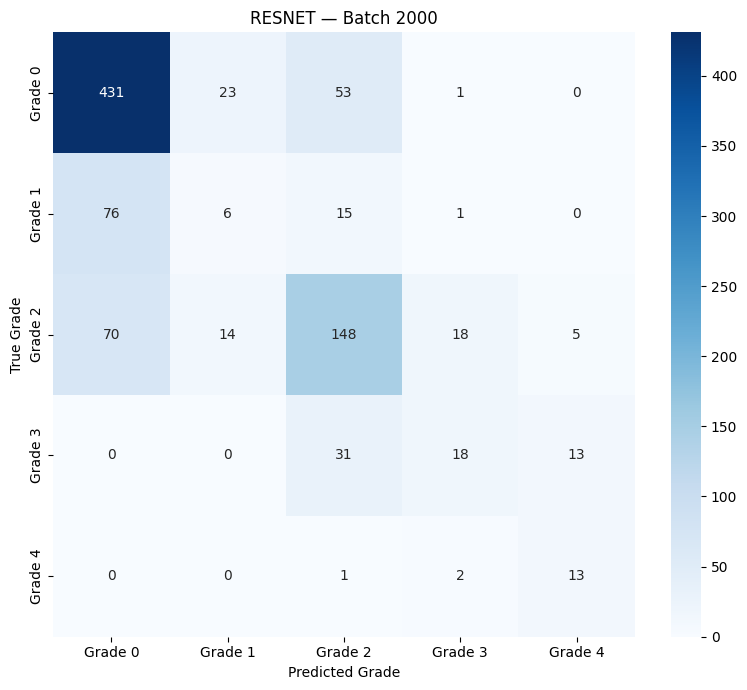


Confusion matrix graph saved to:
/content/drive/MyDrive/KL_Batches/runs/resnet/batch_2000_confusion_matrix.png

Results summary saved to:
/content/drive/MyDrive/KL_Batches/runs/resnet_batch_2000_summary.csv


In [ ]:
# ============================================================
# LOAD, PRINT, GRAPH AND SAVE RESULTS AUTOMATICALLY
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Automatically use the current model and batch
model_name = MODEL_NAME
batch = BATCHES[-1]

outdir = os.path.join(DRIVE_OUT, model_name)

metrics_path = os.path.join(
    outdir, f"batch_{batch}_metrics.json"
)

cm_path = os.path.join(
    outdir, f"batch_{batch}_confusion.csv"
)

# ------------------------------------------------------------
# LOAD SAVED METRICS
# ------------------------------------------------------------

with open(metrics_path, "r") as f:
    results = json.load(f)

print("=" * 60)
print(f"{model_name.upper()} — BATCH {batch}")
print("=" * 60)

for key, value in results.items():
    print(f"{key}: {value}")

# ------------------------------------------------------------
# LOAD SAVED CONFUSION MATRIX
# ------------------------------------------------------------

cm = np.loadtxt(cm_path, delimiter=",", dtype=int)

classes = [
    "Grade 0",
    "Grade 1",
    "Grade 2",
    "Grade 3",
    "Grade 4"
]

print("\nConfusion Matrix:")
print(cm)

# ------------------------------------------------------------
# GRAPHICAL CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(8, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title(f"{model_name.upper()} — Batch {batch}")
plt.xlabel("Predicted Grade")
plt.ylabel("True Grade")

plt.tight_layout()

graph_path = os.path.join(
    outdir,
    f"batch_{batch}_confusion_matrix.png"
)

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("\nConfusion matrix graph saved to:")
print(graph_path)

# ------------------------------------------------------------
# SAVE A CSV SUMMARY FOR COMPARING BATCHES
# ------------------------------------------------------------

summary_path = os.path.join(
    DRIVE_OUT,
    f"{model_name}_batch_{batch}_summary.csv"
)

pd.DataFrame([results]).to_csv(
    summary_path,
    index=False
)

print("\nResults summary saved to:")
print(summary_path)

## **For Btach 3000 Images**

In [ ]:
# ============================================================
# CONFIG
# ============================================================

MEMBER      = "Kalhara"
MODEL_NAME  = "resnet"

# Dataset is already available directly in Google Drive.
# We are NOT using dataset.zip here.
DRIVE_ZIP   = None

# Your batch folders are here:
# /content/drive/MyDrive/KL_Batches/batch_500
DRIVE_DATA  = "/content/drive/MyDrive/KL_Batches"

# Where results will be saved
DRIVE_OUT   = "/content/drive/MyDrive/KL_Batches/runs"

# Fast local disk
LOCAL_DATA  = "/content/data"

# ------------------------------------------------------------
# RUN ONE BATCH AT A TIME
# ------------------------------------------------------------
BATCHES     = [3000]

# ------------------------------------------------------------
# TRAINING
# ------------------------------------------------------------
EPOCHS      = 30
BATCH_SIZE  = 32

# Explicitly use 1e-4
LR          = 1e-4

# ------------------------------------------------------------
# SHARED POLICY
# ------------------------------------------------------------
IMAGE_SIZE  = 224
NUM_CLASSES = 5
SEED        = 42

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

SAVE_CHECKPOINTS = True

print("Model:", MODEL_NAME)
print("Batches:", BATCHES)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LR)

Model: resnet
Batches: [3000]
Epochs: 30
Batch size: 32
Learning rate: 0.0001


In [ ]:
# ============================================================
# DATA ROOT
# ============================================================

import os

DATA_ROOT = DRIVE_DATA

print("DATA_ROOT =", DATA_ROOT)

print("\nAvailable batches:")
print(sorted(
    d for d in os.listdir(DATA_ROOT)
    if d.startswith("batch_")
))

DATA_ROOT = /content/drive/MyDrive/KL_Batches

Available batches:
['batch_2000', 'batch_3000']


In [ ]:
# ============================================================
# IMPORTS + SEED
# ============================================================

import os
import json
import random
import copy

import numpy as np
import torch
import torch.nn as nn

from PIL import Image

from torch.utils.data import DataLoader, WeightedRandomSampler

from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    cohen_kappa_score,
    confusion_matrix
)

def set_seed(s=SEED):
    random.seed(s)
    np.random.seed(s)

    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
# ============================================================
# 16-BIT GRAYSCALE TIFF LOADER
# ============================================================

def load_16bit_xray(path):
    """
    Load a 16-bit grayscale TIFF.

    Original:
        uint16, approximately 0-65535

    Output:
        float32 tensor
        shape = [3, H, W]
        range approximately 0-1
    """

    img = Image.open(path)

    # Read the original 16-bit pixel values
    arr = np.array(img, dtype=np.uint16)

    # Convert to float32
    arr = arr.astype(np.float32)

    # Fixed scaling to the full uint16 range
    arr = arr / 65535.0

    # Convert to tensor: H,W -> 1,H,W
    tensor = torch.from_numpy(arr).unsqueeze(0)

    # Grayscale -> 3 identical channels
    tensor = tensor.repeat(3, 1, 1)

    return tensor

In [ ]:
# ============================================================
# TRANSFORMS
# ============================================================

def train_transform():
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

        # Moderate geometric augmentation
        transforms.RandomAffine(
            degrees=7,
            translate=(0.03, 0.03),
            scale=(0.95, 1.05)
        ),

        # Moderate intensity augmentation
        transforms.ColorJitter(
            brightness=0.10,
            contrast=0.10
        ),

        # ImageNet normalization for pretrained ResNet
        transforms.Normalize(MEAN, STD)
    ])


def eval_transform():
    # NO augmentation for frozen test
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.Normalize(MEAN, STD)
    ])

In [ ]:
# ============================================================
# DATASET CREATION
# ============================================================

def make_datasets(batch):

    bdir = os.path.join(DATA_ROOT, f"batch_{batch}")

    train_dir = os.path.join(bdir, "train")
    test_dir  = os.path.join(bdir, "test")

    tr_ds = ImageFolder(
        train_dir,
        loader=load_16bit_xray,
        transform=train_transform()
    )

    te_ds = ImageFolder(
        test_dir,
        loader=load_16bit_xray,
        transform=eval_transform()
    )

    return tr_ds, te_ds

In [ ]:
# ============================================================
# WEIGHTED OVERSAMPLING
# ============================================================

def make_weighted_sampler(labels):

    labels = np.asarray(labels)

    counts = np.bincount(
        labels,
        minlength=NUM_CLASSES
    )

    weights = (
        1.0 /
        np.maximum(counts, 1)
    )[labels]

    sampler = WeightedRandomSampler(
        torch.DoubleTensor(weights),
        num_samples=len(weights),
        replacement=True
    )

    return sampler

In [ ]:
# ============================================================
# METRICS
# ============================================================

def compute_metrics(yt, yp):

    wp, wr, wf, _ = precision_recall_fscore_support(
        yt,
        yp,
        average="weighted",
        zero_division=0
    )

    mp, mr, mf, _ = precision_recall_fscore_support(
        yt,
        yp,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": float(
            accuracy_score(yt, yp)
        ),

        "weighted_precision": float(wp),
        "weighted_recall": float(wr),
        "weighted_f1": float(wf),

        "macro_precision": float(mp),
        "macro_recall": float(mr),
        "macro_f1": float(mf),

        "cohen_kappa": float(
            cohen_kappa_score(yt, yp)
        ),

        "quadratic_weighted_kappa": float(
            cohen_kappa_score(
                yt,
                yp,
                weights="quadratic"
            )
        )
    }

In [ ]:
# ============================================================
# DATASET CHECK
# ============================================================

tr_check, te_check = make_datasets(3000)

print("TRAIN")
print("Total:", len(tr_check))
print("Classes:", tr_check.classes)
print("Mapping:", tr_check.class_to_idx)

for i, cls in enumerate(tr_check.classes):
    count = sum(
        label == i
        for _, label in tr_check.samples
    )
    print(f"{cls}: {count}")

print("\nTEST")
print("Total:", len(te_check))
print("Classes:", te_check.classes)
print("Mapping:", te_check.class_to_idx)

for i, cls in enumerate(te_check.classes):
    count = sum(
        label == i
        for _, label in te_check.samples
    )
    print(f"{cls}: {count}")

TRAIN
Total: 2380
Classes: ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Mapping: {'Grade 0': 0, 'Grade 1': 1, 'Grade 2': 2, 'Grade 3': 3, 'Grade 4': 4}
Grade 0: 1260
Grade 1: 282
Grade 2: 622
Grade 3: 145
Grade 4: 71

TEST
Total: 939
Classes: ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Mapping: {'Grade 0': 0, 'Grade 1': 1, 'Grade 2': 2, 'Grade 3': 3, 'Grade 4': 4}
Grade 0: 508
Grade 1: 98
Grade 2: 255
Grade 3: 62
Grade 4: 16


Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Tensor min: -2.1179039478302
Tensor max: 1.7797013521194458
Tensor mean: -0.09838929772377014
Tensor std: 0.8720368146896362
Label: Grade 0


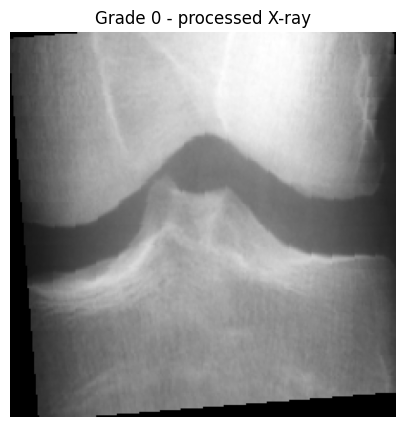

In [ ]:
# ============================================================
# CHECK PREPROCESSED IMAGE
# ============================================================

import matplotlib.pyplot as plt

img, label = tr_check[0]

print("Tensor shape:", img.shape)
print("Tensor dtype:", img.dtype)
print("Tensor min:", img.min().item())
print("Tensor max:", img.max().item())
print("Tensor mean:", img.mean().item())
print("Tensor std:", img.std().item())
print("Label:", tr_check.classes[label])

# Undo ImageNet normalization for visualization
display_img = img.clone()

for c in range(3):
    display_img[c] = (
        display_img[c] * STD[c] + MEAN[c]
    )

display_img = display_img.clamp(0, 1)

plt.figure(figsize=(7, 5))
plt.imshow(
    display_img[0].numpy(),
    cmap="gray"
)
plt.title(
    f"{tr_check.classes[label]} - processed X-ray"
)
plt.axis("off")
plt.show()

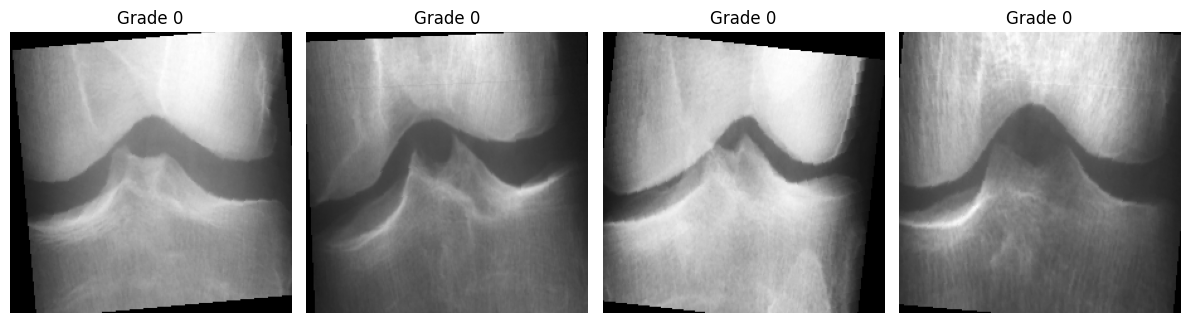

In [ ]:
# ============================================================
# AUGMENTATION CHECK
# ============================================================

raw_ds = ImageFolder(
    os.path.join(
        DATA_ROOT,
        "batch_3000",
        "train"
    ),
    loader=load_16bit_xray,
    transform=None
)

plt.figure(figsize=(12, 4))

for i in range(4):

    raw_img, label = raw_ds[i]

    aug_img = train_transform()(raw_img.clone())

    # Undo normalization
    show_img = aug_img.clone()

    for c in range(3):
        show_img[c] = (
            show_img[c] * STD[c] + MEAN[c]
        )

    show_img = show_img.clamp(0, 1)

    ax = plt.subplot(1, 4, i + 1)

    ax.imshow(
        show_img[0].numpy(),
        cmap="gray"
    )

    ax.set_title(
        raw_ds.classes[label]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# MODEL
# ============================================================

class SimpleCNN(nn.Module):

    def __init__(self, n):

        super().__init__()

        def blk(i, o):
            return nn.Sequential(
                nn.Conv2d(
                    i,
                    o,
                    3,
                    padding=1
                ),
                nn.BatchNorm2d(o),
                nn.ReLU(True),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            blk(3, 32),
            blk(32, 64),
            blk(64, 128),

            nn.Conv2d(
                128,
                256,
                3,
                padding=1
            ),

            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, n)
        )

    def forward(self, x):
        return self.classifier(
            self.features(x)
        )


def build_model(name, n=NUM_CLASSES):

    name = name.lower()

    if name == "resnet":

        model = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            n
        )

    elif name == "densenet":

        model = models.densenet201(
            weights=models.DenseNet201_Weights.DEFAULT
        )

        model.classifier = nn.Linear(
            model.classifier.in_features,
            n
        )

    elif name == "vit":

        model = models.vit_b_16(
            weights=models.ViT_B_16_Weights.DEFAULT
        )

        model.heads.head = nn.Linear(
            model.heads.head.in_features,
            n
        )

    elif name == "cnn":

        model = SimpleCNN(n)

    else:
        raise ValueError(name)

    return model

In [ ]:
# ============================================================
# TRAINING
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    total_loss = 0.0
    correct = 0
    n = 0

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        output = model(x)

        loss = criterion(
            output,
            y
        )

        loss.backward()
        optimizer.step()

        total_loss += (
            loss.item() * x.size(0)
        )

        correct += (
            output.argmax(1) == y
        ).sum().item()

        n += x.size(0)

    return (
        total_loss / n,
        correct / n
    )


@torch.no_grad()
def evaluate(model, loader):

    model.eval()

    ys = []
    ps = []

    for x, y in loader:

        output = model(
            x.to(device)
        )

        predictions = output.argmax(1)

        ps.extend(
            predictions.cpu().numpy()
        )

        ys.extend(
            y.numpy()
        )

    return (
        np.array(ys),
        np.array(ps)
    )

Device: cuda


In [ ]:
# ============================================================
# RUN ONE BATCH
# ============================================================

def run_batch(batch):

    print("\n" + "=" * 60)
    print(f"STARTING {MODEL_NAME.upper()} - BATCH {batch}")
    print("=" * 60)

    set_seed(SEED)

    # --------------------------------------------------------
    # Paths
    # --------------------------------------------------------

    bdir = os.path.join(
        DATA_ROOT,
        f"batch_{batch}"
    )

    train_dir = os.path.join(
        bdir,
        "train"
    )

    test_dir = os.path.join(
        bdir,
        "test"
    )

    # --------------------------------------------------------
    # Datasets
    # --------------------------------------------------------

    tr_ds = ImageFolder(
        train_dir,
        loader=load_16bit_xray,
        transform=train_transform()
    )

    te_ds = ImageFolder(
        test_dir,
        loader=load_16bit_xray,
        transform=eval_transform()
    )

    # --------------------------------------------------------
    # Class mapping check
    # --------------------------------------------------------

    print("\nClass mapping:")
    print(tr_ds.class_to_idx)

    if tr_ds.class_to_idx != te_ds.class_to_idx:
        raise ValueError(
            "TRAIN and TEST class mappings do not match!"
        )

    # --------------------------------------------------------
    # Original training class counts
    # --------------------------------------------------------

    train_labels = [
        label
        for _, label in tr_ds.samples
    ]

    counts = np.bincount(
        train_labels,
        minlength=NUM_CLASSES
    )

    print("\nTraining distribution:")

    for i, cls in enumerate(tr_ds.classes):
        print(
            f"{cls}: {counts[i]}"
        )

    # --------------------------------------------------------
    # Weighted sampler
    # --------------------------------------------------------

    sampler = make_weighted_sampler(
        train_labels
    )

    # --------------------------------------------------------
    # DataLoaders
    # --------------------------------------------------------

    train_loader = DataLoader(
        tr_ds,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        te_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = build_model(
        MODEL_NAME
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    history = []

    for epoch in range(
        1,
        EPOCHS + 1
    ):

        loss, acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "train_loss": float(loss),
            "train_accuracy": float(acc),
            "learning_rate": float(current_lr)
        })

        print(
            f"batch_{batch} "
            f"ep{epoch:02d} | "
            f"train_loss {loss:.3f} | "
            f"train_acc {acc:.3f} | "
            f"lr {current_lr:.7f}"
        )

    # --------------------------------------------------------
    # FROZEN TEST
    # Evaluate only after training is complete
    # --------------------------------------------------------

    print("\nEvaluating frozen test set...")

    yt, yp = evaluate(
        model,
        test_loader
    )

    res = compute_metrics(
        yt,
        yp
    )

    res.update({
        "model": MODEL_NAME,
        "batch": batch,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LR
    })

    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    outdir = os.path.join(
        DRIVE_OUT,
        MODEL_NAME
    )

    os.makedirs(
        outdir,
        exist_ok=True
    )

    # Metrics
    with open(
        os.path.join(
            outdir,
            f"batch_{batch}_metrics.json"
        ),
        "w"
    ) as f:

        json.dump(
            res,
            f,
            indent=2
        )

    # Confusion matrix
    cm = confusion_matrix(
        yt,
        yp,
        labels=list(
            range(NUM_CLASSES)
        )
    )

    np.savetxt(
        os.path.join(
            outdir,
            f"batch_{batch}_confusion.csv"
        ),
        cm,
        fmt="%d",
        delimiter=","
    )

    # Training history
    with open(
        os.path.join(
            outdir,
            f"batch_{batch}_history.json"
        ),
        "w"
    ) as f:

        json.dump(
            history,
            f,
            indent=2
        )

    # Checkpoint
    if SAVE_CHECKPOINTS:

        torch.save(
            model.state_dict(),
            os.path.join(
                outdir,
                f"batch_{batch}_final.pth"
            )
        )

    print("\n" + "-" * 60)
    print("FINAL TEST RESULTS")
    print("-" * 60)

    print(
        f"Accuracy : {res['accuracy']:.4f}"
    )

    print(
        f"Macro F1 : {res['macro_f1']:.4f}"
    )

    print(
        f"Weighted F1 : {res['weighted_f1']:.4f}"
    )

    print(
        f"Cohen Kappa : {res['cohen_kappa']:.4f}"
    )

    print(
        f"QWK : {res['quadratic_weighted_kappa']:.4f}"
    )

    print("\nConfusion Matrix:")
    print(cm)

    return res

In [ ]:
# ============================================================
# RUN BATCH 3000
# ============================================================

all_results = []

for b in BATCHES:

    print(
        f"\n===== {MODEL_NAME} batch_{b} ====="
    )

    result = run_batch(b)

    all_results.append(result)

print("\nBatch 3000 done.")


===== resnet batch_3000 =====

STARTING RESNET - BATCH 3000

Class mapping:
{'Grade 0': 0, 'Grade 1': 1, 'Grade 2': 2, 'Grade 3': 3, 'Grade 4': 4}

Training distribution:
Grade 0: 1260
Grade 1: 282
Grade 2: 622
Grade 3: 145
Grade 4: 71
batch_3000 ep01 | train_loss 1.336 | train_acc 0.411 | lr 0.0000997
batch_3000 ep02 | train_loss 0.876 | train_acc 0.614 | lr 0.0000989
batch_3000 ep03 | train_loss 0.664 | train_acc 0.716 | lr 0.0000976
batch_3000 ep04 | train_loss 0.624 | train_acc 0.744 | lr 0.0000957
batch_3000 ep05 | train_loss 0.478 | train_acc 0.807 | lr 0.0000933
batch_3000 ep06 | train_loss 0.391 | train_acc 0.844 | lr 0.0000905
batch_3000 ep07 | train_loss 0.366 | train_acc 0.856 | lr 0.0000872
batch_3000 ep08 | train_loss 0.303 | train_acc 0.884 | lr 0.0000835
batch_3000 ep09 | train_loss 0.248 | train_acc 0.911 | lr 0.0000794
batch_3000 ep10 | train_loss 0.223 | train_acc 0.921 | lr 0.0000750
batch_3000 ep11 | train_loss 0.179 | train_acc 0.930 | lr 0.0000703
batch_3000 ep12

RESNET — BATCH 3000
accuracy: 0.6879659211927582
weighted_precision: 0.6428424254828943
weighted_recall: 0.6879659211927582
weighted_f1: 0.6577862051607075
macro_precision: 0.4863563547209052
macro_recall: 0.4952533502606021
macro_f1: 0.47892402999714534
cohen_kappa: 0.45877791416835845
quadratic_weighted_kappa: 0.7278582057058992
model: resnet
batch: 3000
epochs: 30
batch_size: 32
learning_rate: 0.0001

Confusion Matrix:
[[459  19  28   2   0]
 [ 76   5  17   0   0]
 [ 73  10 150  17   5]
 [  1   0  28  23  10]
 [  0   0   2   5   9]]


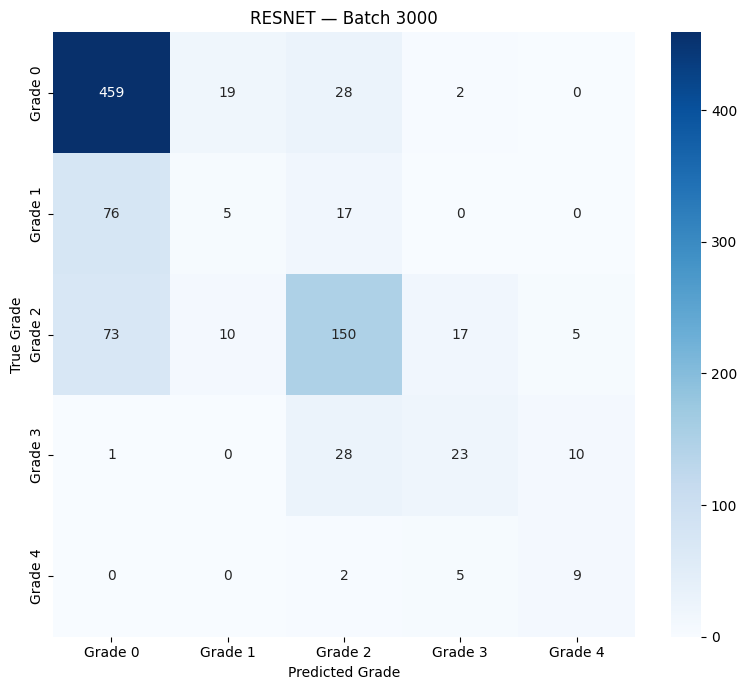


Confusion matrix graph saved to:
/content/drive/MyDrive/KL_Batches/runs/resnet/batch_3000_confusion_matrix.png

Results summary saved to:
/content/drive/MyDrive/KL_Batches/runs/resnet_batch_3000_summary.csv


In [ ]:
# ============================================================
# LOAD, PRINT, GRAPH AND SAVE RESULTS AUTOMATICALLY
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Automatically use the current model and batch
model_name = MODEL_NAME
batch = BATCHES[-1]

outdir = os.path.join(DRIVE_OUT, model_name)

metrics_path = os.path.join(
    outdir, f"batch_{batch}_metrics.json"
)

cm_path = os.path.join(
    outdir, f"batch_{batch}_confusion.csv"
)

# ------------------------------------------------------------
# LOAD SAVED METRICS
# ------------------------------------------------------------

with open(metrics_path, "r") as f:
    results = json.load(f)

print("=" * 60)
print(f"{model_name.upper()} — BATCH {batch}")
print("=" * 60)

for key, value in results.items():
    print(f"{key}: {value}")

# ------------------------------------------------------------
# LOAD SAVED CONFUSION MATRIX
# ------------------------------------------------------------

cm = np.loadtxt(cm_path, delimiter=",", dtype=int)

classes = [
    "Grade 0",
    "Grade 1",
    "Grade 2",
    "Grade 3",
    "Grade 4"
]

print("\nConfusion Matrix:")
print(cm)

# ------------------------------------------------------------
# GRAPHICAL CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(8, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title(f"{model_name.upper()} — Batch {batch}")
plt.xlabel("Predicted Grade")
plt.ylabel("True Grade")

plt.tight_layout()

graph_path = os.path.join(
    outdir,
    f"batch_{batch}_confusion_matrix.png"
)

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("\nConfusion matrix graph saved to:")
print(graph_path)

# ------------------------------------------------------------
# SAVE A CSV SUMMARY FOR COMPARING BATCHES
# ------------------------------------------------------------

summary_path = os.path.join(
    DRIVE_OUT,
    f"{model_name}_batch_{batch}_summary.csv"
)

pd.DataFrame([results]).to_csv(
    summary_path,
    index=False
)

print("\nResults summary saved to:")
print(summary_path)

## **For Batch 4686 Images**

In [3]:
# ============================================================
# CONFIG
# ============================================================

MEMBER      = "Kalhara"
MODEL_NAME  = "resnet"

# Dataset is already available directly in Google Drive.
# We are NOT using dataset.zip here.
DRIVE_ZIP   = None

# Your batch folders are here:
# /content/drive/MyDrive/KL_Batches/batch_500
DRIVE_DATA  = "/content/drive/MyDrive/KL_Batches"

# Where results will be saved
DRIVE_OUT   = "/content/drive/MyDrive/KL_Batches/runs"

# Fast local disk
LOCAL_DATA  = "/content/data"

# ------------------------------------------------------------
# RUN ONE BATCH AT A TIME
# ------------------------------------------------------------
BATCHES     = [4686]

# ------------------------------------------------------------
# TRAINING
# ------------------------------------------------------------
EPOCHS      = 30
BATCH_SIZE  = 32

# Explicitly use 1e-4
LR          = 1e-4

# ------------------------------------------------------------
# SHARED POLICY
# ------------------------------------------------------------
IMAGE_SIZE  = 224
NUM_CLASSES = 5
SEED        = 42

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

SAVE_CHECKPOINTS = True

print("Model:", MODEL_NAME)
print("Batches:", BATCHES)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LR)

Model: resnet
Batches: [4686]
Epochs: 30
Batch size: 32
Learning rate: 0.0001


In [5]:
# ============================================================
# DATA ROOT
# ============================================================

import os

DATA_ROOT = DRIVE_DATA

print("DATA_ROOT =", DATA_ROOT)

print("\nAvailable batches:")
print(sorted(
    d for d in os.listdir(DATA_ROOT)
    if d.startswith("batch_")
))

DATA_ROOT = /content/drive/MyDrive/KL_Batches

Available batches:
['batch_3000']


In [6]:
# ============================================================
# IMPORTS + SEED
# ============================================================

import os
import json
import random
import copy

import numpy as np
import torch
import torch.nn as nn

from PIL import Image

from torch.utils.data import DataLoader, WeightedRandomSampler

from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    cohen_kappa_score,
    confusion_matrix
)

def set_seed(s=SEED):
    random.seed(s)
    np.random.seed(s)

    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
# ============================================================
# 16-BIT GRAYSCALE TIFF LOADER
# ============================================================

def load_16bit_xray(path):
    """
    Load a 16-bit grayscale TIFF.

    Original:
        uint16, approximately 0-65535

    Output:
        float32 tensor
        shape = [3, H, W]
        range approximately 0-1
    """

    img = Image.open(path)

    # Read the original 16-bit pixel values
    arr = np.array(img, dtype=np.uint16)

    # Convert to float32
    arr = arr.astype(np.float32)

    # Fixed scaling to the full uint16 range
    arr = arr / 65535.0

    # Convert to tensor: H,W -> 1,H,W
    tensor = torch.from_numpy(arr).unsqueeze(0)

    # Grayscale -> 3 identical channels
    tensor = tensor.repeat(3, 1, 1)

    return tensor

In [ ]:
# ============================================================
# TRANSFORMS
# ============================================================

def train_transform():
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

        # Moderate geometric augmentation
        transforms.RandomAffine(
            degrees=7,
            translate=(0.03, 0.03),
            scale=(0.95, 1.05)
        ),

        # Moderate intensity augmentation
        transforms.ColorJitter(
            brightness=0.10,
            contrast=0.10
        ),

        # ImageNet normalization for pretrained ResNet
        transforms.Normalize(MEAN, STD)
    ])


def eval_transform():
    # NO augmentation for frozen test
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.Normalize(MEAN, STD)
    ])

In [ ]:
# ============================================================
# DATASET CREATION
# ============================================================

def make_datasets(batch):

    bdir = os.path.join(DATA_ROOT, f"batch_{batch}")

    train_dir = os.path.join(bdir, "train")
    test_dir  = os.path.join(bdir, "test")

    tr_ds = ImageFolder(
        train_dir,
        loader=load_16bit_xray,
        transform=train_transform()
    )

    te_ds = ImageFolder(
        test_dir,
        loader=load_16bit_xray,
        transform=eval_transform()
    )

    return tr_ds, te_ds

In [ ]:
# ============================================================
# WEIGHTED OVERSAMPLING
# ============================================================

def make_weighted_sampler(labels):

    labels = np.asarray(labels)

    counts = np.bincount(
        labels,
        minlength=NUM_CLASSES
    )

    weights = (
        1.0 /
        np.maximum(counts, 1)
    )[labels]

    sampler = WeightedRandomSampler(
        torch.DoubleTensor(weights),
        num_samples=len(weights),
        replacement=True
    )

    return sampler

In [ ]:
# ============================================================
# METRICS
# ============================================================

def compute_metrics(yt, yp):

    wp, wr, wf, _ = precision_recall_fscore_support(
        yt,
        yp,
        average="weighted",
        zero_division=0
    )

    mp, mr, mf, _ = precision_recall_fscore_support(
        yt,
        yp,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": float(
            accuracy_score(yt, yp)
        ),

        "weighted_precision": float(wp),
        "weighted_recall": float(wr),
        "weighted_f1": float(wf),

        "macro_precision": float(mp),
        "macro_recall": float(mr),
        "macro_f1": float(mf),

        "cohen_kappa": float(
            cohen_kappa_score(yt, yp)
        ),

        "quadratic_weighted_kappa": float(
            cohen_kappa_score(
                yt,
                yp,
                weights="quadratic"
            )
        )
    }

In [ ]:
# ============================================================
# DATASET CHECK
# ============================================================

tr_check, te_check = make_datasets(4686)

print("TRAIN")
print("Total:", len(tr_check))
print("Classes:", tr_check.classes)
print("Mapping:", tr_check.class_to_idx)

for i, cls in enumerate(tr_check.classes):
    count = sum(
        label == i
        for _, label in tr_check.samples
    )
    print(f"{cls}: {count}")

print("\nTEST")
print("Total:", len(te_check))
print("Classes:", te_check.classes)
print("Mapping:", te_check.class_to_idx)

for i, cls in enumerate(te_check.classes):
    count = sum(
        label == i
        for _, label in te_check.samples
    )
    print(f"{cls}: {count}")

TRAIN
Total: 3740
Classes: ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Mapping: {'Grade 0': 0, 'Grade 1': 1, 'Grade 2': 2, 'Grade 3': 3, 'Grade 4': 4}
Grade 0: 2016
Grade 1: 437
Grade 2: 991
Grade 3: 225
Grade 4: 71

TEST
Total: 939
Classes: ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Mapping: {'Grade 0': 0, 'Grade 1': 1, 'Grade 2': 2, 'Grade 3': 3, 'Grade 4': 4}
Grade 0: 508
Grade 1: 98
Grade 2: 255
Grade 3: 62
Grade 4: 16


Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Tensor min: -1.9370977878570557
Tensor max: 1.5873576402664185
Tensor mean: 0.4201546609401703
Tensor std: 0.641355037689209
Label: Grade 0


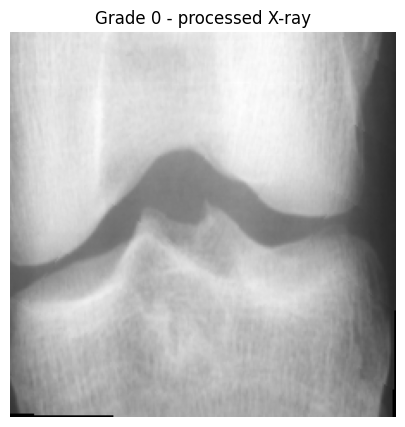

In [ ]:
# ============================================================
# CHECK PREPROCESSED IMAGE
# ============================================================

import matplotlib.pyplot as plt

img, label = tr_check[0]

print("Tensor shape:", img.shape)
print("Tensor dtype:", img.dtype)
print("Tensor min:", img.min().item())
print("Tensor max:", img.max().item())
print("Tensor mean:", img.mean().item())
print("Tensor std:", img.std().item())
print("Label:", tr_check.classes[label])

# Undo ImageNet normalization for visualization
display_img = img.clone()

for c in range(3):
    display_img[c] = (
        display_img[c] * STD[c] + MEAN[c]
    )

display_img = display_img.clamp(0, 1)

plt.figure(figsize=(7, 5))
plt.imshow(
    display_img[0].numpy(),
    cmap="gray"
)
plt.title(
    f"{tr_check.classes[label]} - processed X-ray"
)
plt.axis("off")
plt.show()

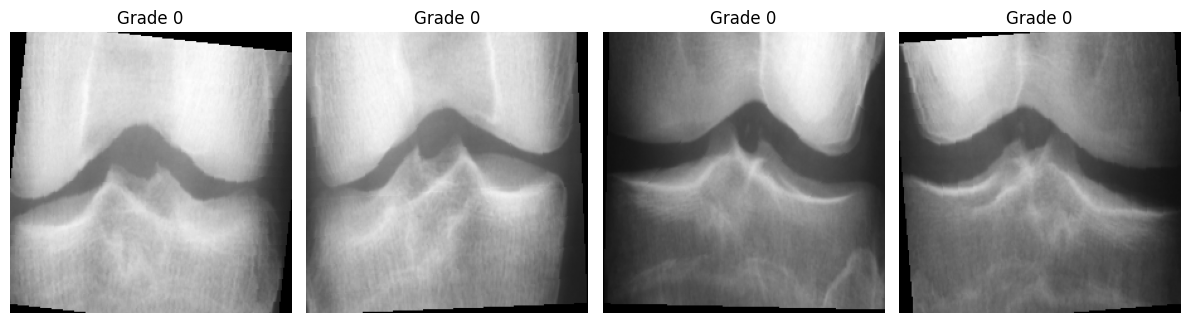

In [ ]:
# ============================================================
# AUGMENTATION CHECK
# ============================================================

raw_ds = ImageFolder(
    os.path.join(
        DATA_ROOT,
        "batch_4686",
        "train"
    ),
    loader=load_16bit_xray,
    transform=None
)

plt.figure(figsize=(12, 4))

for i in range(4):

    raw_img, label = raw_ds[i]

    aug_img = train_transform()(raw_img.clone())

    # Undo normalization
    show_img = aug_img.clone()

    for c in range(3):
        show_img[c] = (
            show_img[c] * STD[c] + MEAN[c]
        )

    show_img = show_img.clamp(0, 1)

    ax = plt.subplot(1, 4, i + 1)

    ax.imshow(
        show_img[0].numpy(),
        cmap="gray"
    )

    ax.set_title(
        raw_ds.classes[label]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# MODEL
# ============================================================

class SimpleCNN(nn.Module):

    def __init__(self, n):

        super().__init__()

        def blk(i, o):
            return nn.Sequential(
                nn.Conv2d(
                    i,
                    o,
                    3,
                    padding=1
                ),
                nn.BatchNorm2d(o),
                nn.ReLU(True),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            blk(3, 32),
            blk(32, 64),
            blk(64, 128),

            nn.Conv2d(
                128,
                256,
                3,
                padding=1
            ),

            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, n)
        )

    def forward(self, x):
        return self.classifier(
            self.features(x)
        )


def build_model(name, n=NUM_CLASSES):

    name = name.lower()

    if name == "resnet":

        model = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            n
        )

    elif name == "densenet":

        model = models.densenet201(
            weights=models.DenseNet201_Weights.DEFAULT
        )

        model.classifier = nn.Linear(
            model.classifier.in_features,
            n
        )

    elif name == "vit":

        model = models.vit_b_16(
            weights=models.ViT_B_16_Weights.DEFAULT
        )

        model.heads.head = nn.Linear(
            model.heads.head.in_features,
            n
        )

    elif name == "cnn":

        model = SimpleCNN(n)

    else:
        raise ValueError(name)

    return model

In [ ]:
# ============================================================
# TRAINING
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    total_loss = 0.0
    correct = 0
    n = 0

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        output = model(x)

        loss = criterion(
            output,
            y
        )

        loss.backward()
        optimizer.step()

        total_loss += (
            loss.item() * x.size(0)
        )

        correct += (
            output.argmax(1) == y
        ).sum().item()

        n += x.size(0)

    return (
        total_loss / n,
        correct / n
    )


@torch.no_grad()
def evaluate(model, loader):

    model.eval()

    ys = []
    ps = []

    for x, y in loader:

        output = model(
            x.to(device)
        )

        predictions = output.argmax(1)

        ps.extend(
            predictions.cpu().numpy()
        )

        ys.extend(
            y.numpy()
        )

    return (
        np.array(ys),
        np.array(ps)
    )

Device: cuda


In [ ]:
# ============================================================
# RUN ONE BATCH
# ============================================================

def run_batch(batch):

    print("\n" + "=" * 60)
    print(f"STARTING {MODEL_NAME.upper()} - BATCH {batch}")
    print("=" * 60)

    set_seed(SEED)

    # --------------------------------------------------------
    # Paths
    # --------------------------------------------------------

    bdir = os.path.join(
        DATA_ROOT,
        f"batch_{batch}"
    )

    train_dir = os.path.join(
        bdir,
        "train"
    )

    test_dir = os.path.join(
        bdir,
        "test"
    )

    # --------------------------------------------------------
    # Datasets
    # --------------------------------------------------------

    tr_ds = ImageFolder(
        train_dir,
        loader=load_16bit_xray,
        transform=train_transform()
    )

    te_ds = ImageFolder(
        test_dir,
        loader=load_16bit_xray,
        transform=eval_transform()
    )

    # --------------------------------------------------------
    # Class mapping check
    # --------------------------------------------------------

    print("\nClass mapping:")
    print(tr_ds.class_to_idx)

    if tr_ds.class_to_idx != te_ds.class_to_idx:
        raise ValueError(
            "TRAIN and TEST class mappings do not match!"
        )

    # --------------------------------------------------------
    # Original training class counts
    # --------------------------------------------------------

    train_labels = [
        label
        for _, label in tr_ds.samples
    ]

    counts = np.bincount(
        train_labels,
        minlength=NUM_CLASSES
    )

    print("\nTraining distribution:")

    for i, cls in enumerate(tr_ds.classes):
        print(
            f"{cls}: {counts[i]}"
        )

    # --------------------------------------------------------
    # Weighted sampler
    # --------------------------------------------------------

    sampler = make_weighted_sampler(
        train_labels
    )

    # --------------------------------------------------------
    # DataLoaders
    # --------------------------------------------------------

    train_loader = DataLoader(
        tr_ds,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        te_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = build_model(
        MODEL_NAME
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    history = []

    for epoch in range(
        1,
        EPOCHS + 1
    ):

        loss, acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "train_loss": float(loss),
            "train_accuracy": float(acc),
            "learning_rate": float(current_lr)
        })

        print(
            f"batch_{batch} "
            f"ep{epoch:02d} | "
            f"train_loss {loss:.3f} | "
            f"train_acc {acc:.3f} | "
            f"lr {current_lr:.7f}"
        )

    # --------------------------------------------------------
    # FROZEN TEST
    # Evaluate only after training is complete
    # --------------------------------------------------------

    print("\nEvaluating frozen test set...")

    yt, yp = evaluate(
        model,
        test_loader
    )

    res = compute_metrics(
        yt,
        yp
    )

    res.update({
        "model": MODEL_NAME,
        "batch": batch,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LR
    })

    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    outdir = os.path.join(
        DRIVE_OUT,
        MODEL_NAME
    )

    os.makedirs(
        outdir,
        exist_ok=True
    )

    # Metrics
    with open(
        os.path.join(
            outdir,
            f"batch_{batch}_metrics.json"
        ),
        "w"
    ) as f:

        json.dump(
            res,
            f,
            indent=2
        )

    # Confusion matrix
    cm = confusion_matrix(
        yt,
        yp,
        labels=list(
            range(NUM_CLASSES)
        )
    )

    np.savetxt(
        os.path.join(
            outdir,
            f"batch_{batch}_confusion.csv"
        ),
        cm,
        fmt="%d",
        delimiter=","
    )

    # Training history
    with open(
        os.path.join(
            outdir,
            f"batch_{batch}_history.json"
        ),
        "w"
    ) as f:

        json.dump(
            history,
            f,
            indent=2
        )

    # Checkpoint
    if SAVE_CHECKPOINTS:

        torch.save(
            model.state_dict(),
            os.path.join(
                outdir,
                f"batch_{batch}_final.pth"
            )
        )

    print("\n" + "-" * 60)
    print("FINAL TEST RESULTS")
    print("-" * 60)

    print(
        f"Accuracy : {res['accuracy']:.4f}"
    )

    print(
        f"Macro F1 : {res['macro_f1']:.4f}"
    )

    print(
        f"Weighted F1 : {res['weighted_f1']:.4f}"
    )

    print(
        f"Cohen Kappa : {res['cohen_kappa']:.4f}"
    )

    print(
        f"QWK : {res['quadratic_weighted_kappa']:.4f}"
    )

    print("\nConfusion Matrix:")
    print(cm)

    return res

In [ ]:
# ============================================================
# RUN BATCH 2000
# ============================================================

all_results = []

for b in BATCHES:

    print(
        f"\n===== {MODEL_NAME} batch_{b} ====="
    )

    result = run_batch(b)

    all_results.append(result)

print("\nBatch 4686 done.")


===== resnet batch_4686 =====

STARTING RESNET - BATCH 4686

Class mapping:
{'Grade 0': 0, 'Grade 1': 1, 'Grade 2': 2, 'Grade 3': 3, 'Grade 4': 4}

Training distribution:
Grade 0: 2016
Grade 1: 437
Grade 2: 991
Grade 3: 225
Grade 4: 71
batch_4686 ep01 | train_loss 1.199 | train_acc 0.475 | lr 0.0000997
batch_4686 ep02 | train_loss 0.795 | train_acc 0.658 | lr 0.0000989
batch_4686 ep03 | train_loss 0.646 | train_acc 0.721 | lr 0.0000976
batch_4686 ep04 | train_loss 0.546 | train_acc 0.773 | lr 0.0000957
batch_4686 ep05 | train_loss 0.457 | train_acc 0.811 | lr 0.0000933
batch_4686 ep06 | train_loss 0.400 | train_acc 0.851 | lr 0.0000905
batch_4686 ep07 | train_loss 0.371 | train_acc 0.857 | lr 0.0000872
batch_4686 ep08 | train_loss 0.286 | train_acc 0.894 | lr 0.0000835
batch_4686 ep09 | train_loss 0.233 | train_acc 0.916 | lr 0.0000794
batch_4686 ep10 | train_loss 0.199 | train_acc 0.931 | lr 0.0000750
batch_4686 ep11 | train_loss 0.203 | train_acc 0.924 | lr 0.0000703
batch_4686 ep12

RESNET — BATCH 4686
accuracy: 0.6815761448349308
weighted_precision: 0.6245778683566525
weighted_recall: 0.6815761448349308
weighted_f1: 0.645078792347574
macro_precision: 0.47316497841315613
macro_recall: 0.43335881139349314
macro_f1: 0.44084504868860064
cohen_kappa: 0.44313450923378694
quadratic_weighted_kappa: 0.7097180987926599
model: resnet
batch: 4686
epochs: 30
batch_size: 32
learning_rate: 0.0001

Confusion Matrix:
[[454  11  43   0   0]
 [ 78   3  17   0   0]
 [ 71   7 159  15   3]
 [  0   0  39  19   4]
 [  0   0   2   9   5]]


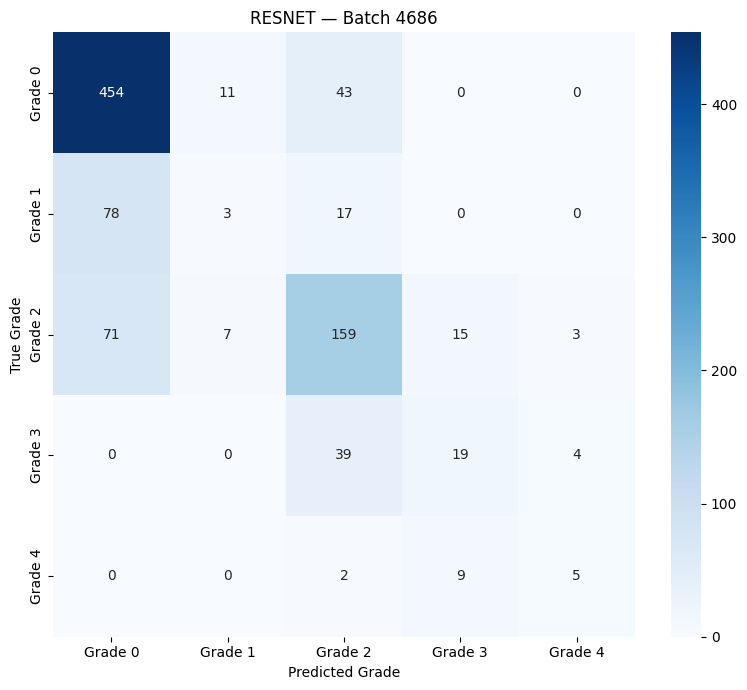


Confusion matrix graph saved to:
/content/drive/MyDrive/KL_Batches/runs/resnet/batch_4686_confusion_matrix.png

Results summary saved to:
/content/drive/MyDrive/KL_Batches/runs/resnet_batch_4686_summary.csv


In [12]:
# ============================================================
# LOAD, PRINT, GRAPH AND SAVE RESULTS AUTOMATICALLY
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Automatically use the current model and batch
model_name = MODEL_NAME
batch = BATCHES[-1]

outdir = os.path.join(DRIVE_OUT, model_name)

metrics_path = os.path.join(
    outdir, f"batch_{batch}_metrics.json"
)

cm_path = os.path.join(
    outdir, f"batch_{batch}_confusion.csv"
)

# ------------------------------------------------------------
# LOAD SAVED METRICS
# ------------------------------------------------------------

with open(metrics_path, "r") as f:
    results = json.load(f)

print("=" * 60)
print(f"{model_name.upper()} — BATCH {batch}")
print("=" * 60)

for key, value in results.items():
    print(f"{key}: {value}")

# ------------------------------------------------------------
# LOAD SAVED CONFUSION MATRIX
# ------------------------------------------------------------

cm = np.loadtxt(cm_path, delimiter=",", dtype=int)

classes = [
    "Grade 0",
    "Grade 1",
    "Grade 2",
    "Grade 3",
    "Grade 4"
]

print("\nConfusion Matrix:")
print(cm)

# ------------------------------------------------------------
# GRAPHICAL CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(8, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title(f"{model_name.upper()} — Batch {batch}")
plt.xlabel("Predicted Grade")
plt.ylabel("True Grade")

plt.tight_layout()

graph_path = os.path.join(
    outdir,
    f"batch_{batch}_confusion_matrix.png"
)

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("\nConfusion matrix graph saved to:")
print(graph_path)

# ------------------------------------------------------------
# SAVE A CSV SUMMARY FOR COMPARING BATCHES
# ------------------------------------------------------------

summary_path = os.path.join(
    DRIVE_OUT,
    f"{model_name}_batch_{batch}_summary.csv"
)

pd.DataFrame([results]).to_csv(
    summary_path,
    index=False
)

print("\nResults summary saved to:")
print(summary_path)

## **Results**

FINAL RESULTS - RESNET

Completed batches:
[500, 1000, 1500, 2000, 3000, 4686]


 batch  accuracy  weighted_precision  weighted_recall  weighted_f1  macro_precision  macro_recall  macro_f1  cohen_kappa  quadratic_weighted_kappa
   500    0.6198              0.5715           0.6198       0.5758           0.4159        0.4789    0.3798       0.3313                    0.6350
  1000    0.6667              0.6206           0.6667       0.6270           0.4449        0.4745    0.4120       0.4140                    0.7029
  1500    0.6528              0.6063           0.6528       0.6215           0.4388        0.4845    0.4322       0.4047                    0.6923
  2000    0.6560              0.6176           0.6560       0.6312           0.4705        0.5186    0.4748       0.4147                    0.6986
  3000    0.6880              0.6428           0.6880       0.6578           0.4864        0.4953    0.4789       0.4588                    0.7279
  4686    0.6816              0.6246 

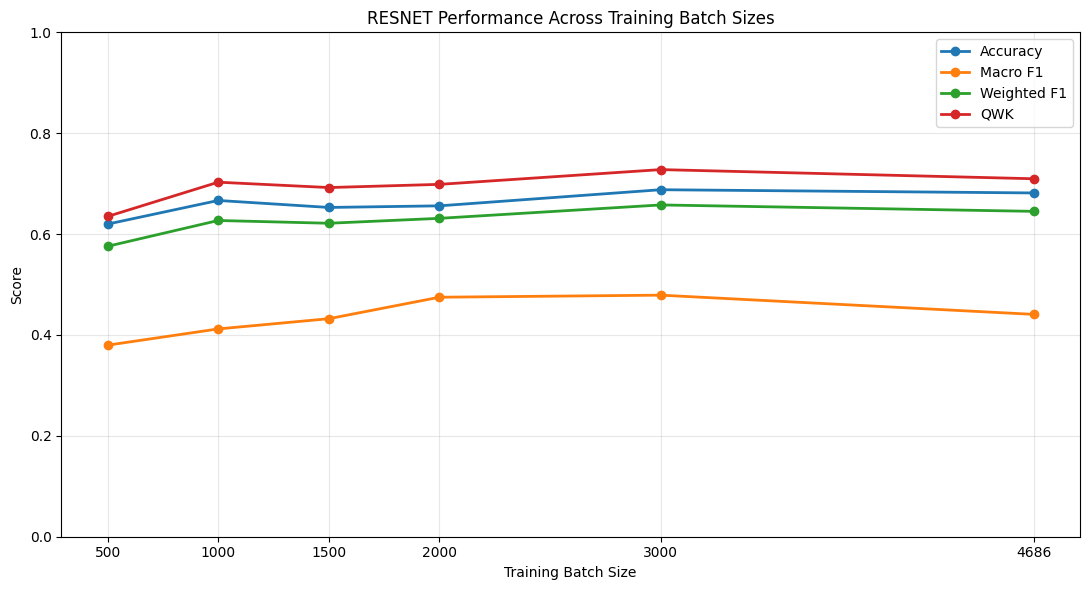


Comparison graph saved to:
/content/drive/MyDrive/KL_Batches/runs/resnet/batch_comparison.png

CONFUSION MATRIX - BEST BATCH 3000
[[459  19  28   2   0]
 [ 76   5  17   0   0]
 [ 73  10 150  17   5]
 [  1   0  28  23  10]
 [  0   0   2   5   9]]


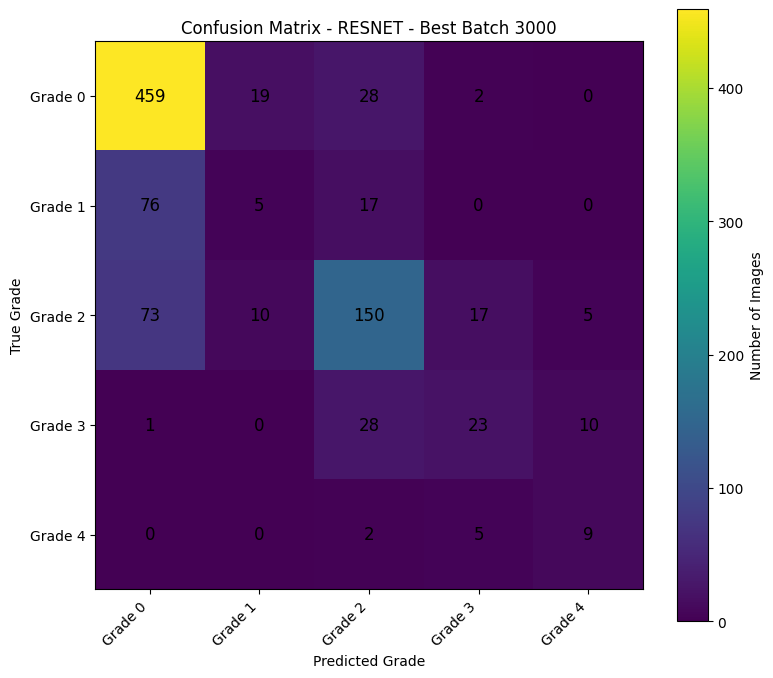


Confusion matrix graph saved to:
/content/drive/MyDrive/KL_Batches/runs/resnet/batch_3000_confusion_matrix.png

FILES SAVED
Results folder      : /content/drive/MyDrive/KL_Batches/runs/resnet
Comparison table    : /content/drive/MyDrive/KL_Batches/runs/resnet/all_batches_comparison.csv
Comparison graph    : /content/drive/MyDrive/KL_Batches/runs/resnet/batch_comparison.png
Best batch          : 3000
Best confusion mat. : /content/drive/MyDrive/KL_Batches/runs/resnet/batch_3000_confusion_matrix.png

DONE.


In [13]:
# ============================================================
# FINAL RESULTS: TABLE + COMPARISON GRAPH + BEST CONFUSION MATRIX
# Run this AFTER all desired batches have finished training
# ============================================================

import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Locate all completed batch results automatically
# ------------------------------------------------------------

results_dir = os.path.join(DRIVE_OUT, MODEL_NAME)

metric_files = sorted(
    glob.glob(os.path.join(results_dir, "batch_*_metrics.json"))
)

if len(metric_files) == 0:
    raise FileNotFoundError(
        f"No metrics files found in: {results_dir}"
    )

all_results = []

for path in metric_files:
    with open(path, "r") as f:
        result = json.load(f)

    all_results.append(result)

results_df = pd.DataFrame(all_results)

# Sort by batch size
results_df = results_df.sort_values("batch").reset_index(drop=True)

print("=" * 80)
print(f"FINAL RESULTS - {MODEL_NAME.upper()}")
print("=" * 80)

print("\nCompleted batches:")
print(results_df["batch"].tolist())

# ------------------------------------------------------------
# 2. Create a clean comparison table
# ------------------------------------------------------------

table_columns = [
    "batch",
    "accuracy",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "cohen_kappa",
    "quadratic_weighted_kappa"
]

# Keep only columns that actually exist
table_columns = [
    c for c in table_columns
    if c in results_df.columns
]

comparison_df = results_df[table_columns].copy()

# Round metrics for easier reading
metric_columns = [
    c for c in comparison_df.columns
    if c != "batch"
]

comparison_df[metric_columns] = comparison_df[metric_columns].round(4)

print("\n")
print(comparison_df.to_string(index=False))

# ------------------------------------------------------------
# 3. Automatically find the BEST batch
#    Primary criterion = Macro F1
# ------------------------------------------------------------

if "macro_f1" not in results_df.columns:
    raise KeyError("macro_f1 is not available in the saved results.")

best_idx = results_df["macro_f1"].idxmax()
best_batch = int(results_df.loc[best_idx, "batch"])
best_macro_f1 = float(results_df.loc[best_idx, "macro_f1"])

print("\n" + "=" * 80)
print("BEST BATCH")
print("=" * 80)
print(f"Best batch     : {best_batch}")
print(f"Macro F1       : {best_macro_f1:.4f}")

if "accuracy" in results_df.columns:
    print(f"Accuracy       : {results_df.loc[best_idx, 'accuracy']:.4f}")

if "quadratic_weighted_kappa" in results_df.columns:
    print(f"QWK            : {results_df.loc[best_idx, 'quadratic_weighted_kappa']:.4f}")

# ------------------------------------------------------------
# 4. Save comparison table
# ------------------------------------------------------------

table_path = os.path.join(
    results_dir,
    "all_batches_comparison.csv"
)

comparison_df.to_csv(table_path, index=False)

print(f"\nComparison table saved to:")
print(table_path)

# ------------------------------------------------------------
# 5. Comparison graph
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.plot(
    results_df["batch"],
    results_df["accuracy"],
    marker="o",
    linewidth=2,
    label="Accuracy"
)

plt.plot(
    results_df["batch"],
    results_df["macro_f1"],
    marker="o",
    linewidth=2,
    label="Macro F1"
)

plt.plot(
    results_df["batch"],
    results_df["weighted_f1"],
    marker="o",
    linewidth=2,
    label="Weighted F1"
)

if "quadratic_weighted_kappa" in results_df.columns:
    plt.plot(
        results_df["batch"],
        results_df["quadratic_weighted_kappa"],
        marker="o",
        linewidth=2,
        label="QWK"
    )

plt.xlabel("Training Batch Size")
plt.ylabel("Score")
plt.title(f"{MODEL_NAME.upper()} Performance Across Training Batch Sizes")

plt.xticks(results_df["batch"])
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

graph_path = os.path.join(
    results_dir,
    "batch_comparison.png"
)

plt.savefig(graph_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nComparison graph saved to:")
print(graph_path)

# ------------------------------------------------------------
# 6. Load BEST batch confusion matrix
# ------------------------------------------------------------

confusion_path = os.path.join(
    results_dir,
    f"batch_{best_batch}_confusion.csv"
)

if not os.path.exists(confusion_path):
    raise FileNotFoundError(
        f"Confusion matrix not found:\n{confusion_path}"
    )

cm = np.loadtxt(confusion_path, delimiter=",", dtype=int)

print("\n" + "=" * 80)
print(f"CONFUSION MATRIX - BEST BATCH {best_batch}")
print("=" * 80)

print(cm)

# ------------------------------------------------------------
# 7. Graphical confusion matrix
# ------------------------------------------------------------

class_names = [
    "Grade 0",
    "Grade 1",
    "Grade 2",
    "Grade 3",
    "Grade 4"
]

plt.figure(figsize=(8, 7))

plt.imshow(cm)

plt.title(
    f"Confusion Matrix - {MODEL_NAME.upper()} - Best Batch {best_batch}"
)

plt.xlabel("Predicted Grade")
plt.ylabel("True Grade")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(class_names)),
    class_names
)

# Add numbers inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=12
        )

plt.colorbar(label="Number of Images")

plt.tight_layout()

cm_graph_path = os.path.join(
    results_dir,
    f"batch_{best_batch}_confusion_matrix.png"
)

plt.savefig(
    cm_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nConfusion matrix graph saved to:")
print(cm_graph_path)

# ------------------------------------------------------------
# 8. Final summary
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)

print(f"Results folder      : {results_dir}")
print(f"Comparison table    : {table_path}")
print(f"Comparison graph    : {graph_path}")
print(f"Best batch          : {best_batch}")
print(f"Best confusion mat. : {cm_graph_path}")

print("\nDONE.")